# Results Table — iOS
Aggregates metrics from all iOS project result files into a single table.
Each row is one project (framework + project name).

**Aggregation strategy:**
- **SonarQube**: taken directly from the project-level `sonarqube_project` field
- **Halstead** (raw counts + volume): summed across files
- **Halstead** (derived: difficulty, effort, time_seconds, bugs_delivered, calculated_length): median across files
- **State metrics** (mutable_vars, immutable_vars, observable_state_vars, state_updates): summed across files
- **Derived metrics** (mutable_variable_ratio): computed as sum(mutable_vars) / sum(total_vars) across files
- **Derived metrics** (maintainability_index): median across files

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

COLORS = {'swiftui': '#2196A6', 'uikit': '#E07B39'}  # teal / orange
FIGURES_DIR = Path('../results/figures')
#FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
RESULTS_DIR = Path('../results')

# Load only iOS result files (swiftui_* and uikit_*)
result_files = sorted(
    f for f in RESULTS_DIR.glob('*.json')
    if f.stem.startswith('swiftui_') or f.stem.startswith('uikit_')
)
print(f'Found {len(result_files)} iOS result files:')
for f in result_files:
    print(f'  {f.name}')

Found 14 iOS result files:
  swiftui_ACHNBrowserUI.json
  swiftui_Chess.json
  swiftui_Gem.json
  swiftui_Lyric Fever.json
  swiftui_MovieSwift.json
  swiftui_PokedexUI.json
  swiftui_dime.json
  uikit_Chess.json
  uikit_Expense Tracker.json
  uikit_OnionBrowser.json
  uikit_Tuist-Pokedex.json
  uikit_YouTag.json
  uikit_YouTube.json
  uikit_fearless.json


In [3]:
SONARQUBE_FIELDS = [
    'ncloc', 'lines', 'files', 'functions', 'classes', 'statements',
    'complexity',
    'code_smells', 'bugs', 'sqale_debt_ratio',
    'duplicated_lines_density', 'comment_lines', 'comment_lines_density',
]

HALSTEAD_SUM_FIELDS = [
    'loc',
    'n1_unique_operators', 'n2_unique_operands',
    'N1_total_operators', 'N2_total_operands',
    'vocabulary', 'length', 'volume',
]

HALSTEAD_MEDIAN_FIELDS = [
    'calculated_length', 'difficulty', 'effort',
    'time_seconds', 'bugs_delivered',
]

STATE_SUM_FIELDS = [
    'mutable_vars', 'immutable_vars',
    'observable_state_vars', 'state_updates',
]

DERIVED_MEDIAN_FIELDS = [
    'maintainability_index',
]

# --- Project pairs (uikit, views_proj, uikit_color, swiftui, swiftui_proj, swiftui_color, bg_color) ---
# Project names must match the 'project' field in the JSON (= Path(project_path).name)
PAIRS = [
    ('uikit', 'fearless-iOS',       COLORS['uikit'],   'swiftui', 'gem-ios',       COLORS['swiftui'], '#FFE4B5'),
    ('uikit', 'OnionBrowser',       COLORS['uikit'],   'swiftui', 'ACHNBrowserUI', COLORS['swiftui'], '#B0E0E6'),
    ('uikit', 'youtube-iOS',        COLORS['uikit'],   'swiftui', 'MovieSwiftUI',  COLORS['swiftui'], '#DDA0DD'),
    ('uikit', 'Expense-Tracker-App',COLORS['uikit'],   'swiftui', 'dimeApp',       COLORS['swiftui'], '#ADDFAD'),
    ('uikit', 'Chess',              COLORS['uikit'],   'swiftui', 'chess_swiftui', COLORS['swiftui'], '#F08080'),
    ('uikit', 'Tuist-Pokedex',      COLORS['uikit'],   'swiftui', 'PokedexUI',     COLORS['swiftui'], '#FAFAD2'),
    ('uikit', 'YouTag',             COLORS['uikit'],   'swiftui', 'LyricFever',    COLORS['swiftui'], '#E6E6FA'),
]

In [4]:
def collect_file_values(files_dict, section, fields):
    collected = {f: [] for f in fields}
    for file_data in files_dict.values():
        if not isinstance(file_data, dict):
            continue
        section_data = file_data.get(section, {})
        if not isinstance(section_data, dict):
            continue
        for field in fields:
            val = section_data.get(field)
            if val is not None:
                try:
                    collected[field].append(float(val))
                except (TypeError, ValueError):
                    pass
    return collected


def aggregate_project(data):
    row = {}
    project_path = data.get('project_path', '')
    row['project']   = Path(project_path).name if project_path else data.get('project', '')
    row['framework'] = data.get('framework', '')

    sq = data.get('sonarqube_project', {})
    for field in SONARQUBE_FIELDS:
        val = sq.get(field)
        row[f'sq_{field}'] = float(val) if val is not None else None

    files_dict = data.get('files', {})

    hal = collect_file_values(files_dict, 'halstead', HALSTEAD_SUM_FIELDS + HALSTEAD_MEDIAN_FIELDS)
    for field in HALSTEAD_SUM_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = sum(vals) if vals else None
    for field in HALSTEAD_MEDIAN_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = float(np.median(vals)) if vals else None

    state = collect_file_values(files_dict, 'state_metrics', STATE_SUM_FIELDS)
    for field in STATE_SUM_FIELDS:
        vals = state[field]
        row[f'state_{field}'] = sum(vals) if vals else None

    total_mutable   = row.get('state_mutable_vars') or 0
    total_immutable = row.get('state_immutable_vars') or 0
    total_vars      = total_mutable + total_immutable
    row['derived_mutable_variable_ratio'] = round(total_mutable / total_vars, 4) if total_vars > 0 else None

    derived = collect_file_values(files_dict, 'derived', DERIVED_MEDIAN_FIELDS)
    for field in DERIVED_MEDIAN_FIELDS:
        vals = derived[field]
        row[f'derived_{field}'] = float(np.median(vals)) if vals else None

    # Swift complexity — sum all function-level cognitive/cyclomatic values across files
    swift_total_cognitive  = 0
    swift_total_cyclomatic = 0
    has_swift = False
    for file_data in files_dict.values():
        sc = file_data.get('swift_complexity', {})
        if not sc:
            continue
        has_swift = True
        for fn in sc.get('functions', []):
            swift_total_cognitive  += fn.get('cognitive',  0)
            swift_total_cyclomatic += fn.get('cyclomatic', 0)
    row['swift_total_cognitive']  = swift_total_cognitive  if has_swift else None
    row['swift_total_cyclomatic'] = swift_total_cyclomatic if has_swift else None

    return row


rows = []
for result_file in result_files:
    with open(result_file) as f:
        data = json.load(f)
    rows.append(aggregate_project(data))

df = pd.DataFrame(rows).set_index(['framework', 'project'])
print(f'Table shape: {df.shape}')
print(df.index.tolist())
df

Table shape: (14, 34)
[('swiftui', 'ACHNBrowserUI'), ('swiftui', 'chess_swiftui'), ('swiftui', 'gem-ios'), ('swiftui', 'LyricFever'), ('swiftui', 'MovieSwiftUI'), ('swiftui', 'PokedexUI'), ('swiftui', 'dimeApp'), ('uikit', 'Chess'), ('uikit', 'Expense-Tracker-App'), ('uikit', 'OnionBrowser'), ('uikit', 'Tuist-Pokedex'), ('uikit', 'YouTag'), ('uikit', 'youtube-iOS'), ('uikit', 'fearless-iOS')]


sq_ncloc  sq_lines  sq_files  sq_functions  \
framework project                                                           
swiftui   ACHNBrowserUI       10568.000 13474.000   161.000       255.000   
          chess_swiftui         742.000   992.000     5.000        24.000   
          gem-ios             20538.000 24160.000   270.000       593.000   
          LyricFever           4470.000  5618.000    36.000       115.000   
          MovieSwiftUI         5414.000  7007.000    91.000       148.000   
          PokedexUI            1169.000  1570.000    29.000        56.000   
          dimeApp             21280.000 27230.000    81.000       273.000   
uikit     Chess                 585.000   708.000     6.000        42.000   
          Expense-Tracker-App  4016.000  5762.000    58.000       254.000   
          OnionBrowser         7132.000 10876.000    62.000       386.000   
          Tuist-Pokedex        1444.000  2252.000    42.000       147.000   
          YouTag               6138.000  7989.000    23.000       343.000   
          youtube-iOS           989.000  1530.000    14.000        93.000   
          fearless-iOS         2011.000  2510.000    62.000       135.000   

                               sq_classes sq_statements  sq_complexity  \
framework project                                                        
swiftui   ACHNBrowserUI            26.000          None       1463.000   
          chess_swiftui             1.000          None        174.000   
          gem-ios                  57.000          None       1220.000   
          LyricFever               10.000          None        229.000   
          MovieSwiftUI             10.000          None        941.000   
          PokedexUI                 4.000          None         75.000   
          dimeApp                  19.000          None        867.000   
uikit     Chess                     5.000          None        124.000   
          Expense-Tracker-App      47.000          None        372.000   
          OnionBrowser            118.000          None       1004.000   
          Tuist-Pokedex            34.000          None        221.000   
          YouTag                   25.000          None        808.000   
          youtube-iOS              29.000          None        168.000   
          fearless-iOS             25.000          None        291.000   

                               sq_code_smells  sq_bugs  sq_sqale_debt_ratio  \
framework project                                                             
swiftui   ACHNBrowserUI              1008.000    1.000                1.700   
          chess_swiftui                30.000    0.000                1.300   
          gem-ios                       2.000    0.000                0.000   
          LyricFever                  604.000    0.000                2.400   
          MovieSwiftUI                862.000    0.000                2.700   
          PokedexUI                    21.000    0.000                0.300   
          dimeApp                     705.000    2.000                0.800   
uikit     Chess                        17.000    0.000                0.600   
          Expense-Tracker-App        1180.000    5.000                5.100   
          OnionBrowser                609.000    6.000                1.900   
          Tuist-Pokedex                 2.000    4.000                0.000   
          YouTag                      899.000   17.000                2.900   
          youtube-iOS                 357.000   19.000                5.400   
          fearless-iOS                 16.000    1.000                0.200   

                               sq_duplicated_lines_density  sq_comment_lines  \
framework project                                                              
swiftui   ACHNBrowserUI                              0.000          1228.000   
          chess_swiftui                              0.000           103.000   
          gem-ios           

## SonarQube metrics

In [5]:
sq_cols = [c for c in df.columns if c.startswith('sq_')]
df[sq_cols].rename(columns=lambda c: c[3:])

ncloc     lines   files  functions  classes  \
framework project                                                               
swiftui   ACHNBrowserUI       10568.000 13474.000 161.000    255.000   26.000   
          chess_swiftui         742.000   992.000   5.000     24.000    1.000   
          gem-ios             20538.000 24160.000 270.000    593.000   57.000   
          LyricFever           4470.000  5618.000  36.000    115.000   10.000   
          MovieSwiftUI         5414.000  7007.000  91.000    148.000   10.000   
          PokedexUI            1169.000  1570.000  29.000     56.000    4.000   
          dimeApp             21280.000 27230.000  81.000    273.000   19.000   
uikit     Chess                 585.000   708.000   6.000     42.000    5.000   
          Expense-Tracker-App  4016.000  5762.000  58.000    254.000   47.000   
          OnionBrowser         7132.000 10876.000  62.000    386.000  118.000   
          Tuist-Pokedex        1444.000  2252.000  42.000    147.000   34.000   
          YouTag               6138.000  7989.000  23.000    343.000   25.000   
          youtube-iOS           989.000  1530.000  14.000     93.000   29.000   
          fearless-iOS         2011.000  2510.000  62.000    135.000   25.000   

                              statements  complexity  code_smells   bugs  \
framework project                                                          
swiftui   ACHNBrowserUI             None    1463.000     1008.000  1.000   
          chess_swiftui             None     174.000       30.000  0.000   
          gem-ios                   None    1220.000        2.000  0.000   
          LyricFever                None     229.000      604.000  0.000   
          MovieSwiftUI              None     941.000      862.000  0.000   
          PokedexUI                 None      75.000       21.000  0.000   
          dimeApp                   None     867.000      705.000  2.000   
uikit     Chess                     None     124.000       17.000  0.000   
          Expense-Tracker-App       None     372.000     1180.000  5.000   
          OnionBrowser              None    1004.000      609.000  6.000   
          Tuist-Pokedex             None     221.000        2.000  4.000   
          YouTag                    None     808.000      899.000 17.000   
          youtube-iOS               None     168.000      357.000 19.000   
          fearless-iOS              None     291.000       16.000  1.000   

                               sqale_debt_ratio  duplicated_lines_density  \
framework project                                                           
swiftui   ACHNBrowserUI                   1.700                     0.000   
          chess_swiftui                   1.300                     0.000   
          gem-ios                         0.000                     0.000   
          LyricFever                      2.400                     0.000   
          MovieSwiftUI                    2.700                     0.000   
          PokedexUI                       0.300                     0.000   
          dimeApp                         0.800                     5.100   
uikit     Chess                           0.600                     0.000   
          Expense-Tracker-App             5.100                     0.000   
          OnionBrowser                    1.900                     0.000   
          Tuist-Pokedex                   0.000                    12.300   
          YouTag                          2.900                     0.000   
          youtube-iOS                     5.400                     0.000   
          fearless-iOS                    0.200                     0.000   

                               comment_lines  comment_lines_density  
framework project                                                    
swiftui   ACHNBrowserUI             1228.000                 10.400  
          chess_swiftui              103.000                 12.200  
       

## Halstead metrics

In [6]:
hal_cols = [c for c in df.columns if c.startswith('hal_')]
df[hal_cols].rename(columns=lambda c: c[4:])

loc  n1_unique_operators  \
framework project                                              
swiftui   ACHNBrowserUI       11796.000             2730.000   
          chess_swiftui         845.000               88.000   
          gem-ios             20973.000             4690.000   
          LyricFever           5052.000              700.000   
          MovieSwiftUI         6103.000             1526.000   
          PokedexUI            1359.000              470.000   
          dimeApp             23286.000             1894.000   
uikit     Chess                 627.000              110.000   
          Expense-Tracker-App  4603.000              899.000   
          OnionBrowser         8405.000             1517.000   
          Tuist-Pokedex        1731.000              595.000   
          YouTag               6898.000              725.000   
          youtube-iOS          1283.000              318.000   
          fearless-iOS         2037.000              857.000   

                               n2_unique_operands  N1_total_operators  \
framework project                                                       
swiftui   ACHNBrowserUI                 10619.000           22883.000   
          chess_swiftui                   353.000            1965.000   
          gem-ios                       17921.000           41310.000   
          LyricFever                     3703.000            8682.000   
          MovieSwiftUI                   5385.000           12667.000   
          PokedexUI                      1142.000            2481.000   
          dimeApp                       12183.000           58270.000   
uikit     Chess                           443.000            1517.000   
          Expense-Tracker-App            4337.000           12142.000   
          OnionBrowser                   6100.000           17515.000   
          Tuist-Pokedex                  1537.000            3309.000   
          YouTag                         4964.000           18965.000   
          youtube-iOS                    1234.000            3484.000   
          fearless-iOS                   1868.000            4733.000   

                               N2_total_operands  vocabulary     length  \
framework project                                                         
swiftui   ACHNBrowserUI                22210.000   13349.000  45093.000   
          chess_swiftui                 2094.000     441.000   4059.000   
          gem-ios                      40422.000   22611.000  81732.000   
          LyricFever                    8984.000    4403.000  17666.000   
          MovieSwiftUI                 12528.000    6911.000  25195.000   
          PokedexUI                     2488.000    1612.000   4969.000   
          dimeApp                      57672.000   14077.000 115942.000   
uikit     Chess                         1476.000     553.000   2993.000   
          Expense-Tracker-App          12910.000    5236.000  25052.000   
          OnionBrowser                 17145.000    7617.000  34660.000   
          Tuist-Pokedex                 3209.000    2132.000   6518.000   
          YouTag                       19595.000    5689.000  38560.000   
          youtube-iOS                   3551.000    1552.000   7035.000   
          fearless-iOS                  4529.000    2725.000   9262.000   

                                  volume  calculated_length  difficulty  \
framework project                                                         
swiftui   ACHNBrowserUI       305137.010            363.270      15.470   
          chess_swiftui        29686.900            307.390      10.040   
          gem-ios             560277.630            362.345      15.330   
          LyricFever          134835.480            435.735      15.870   
          MovieSwiftUI        169124.910            353.290      12.760   
          PokedexUI            31409.850            216.690      12.330   
          dimeApp             997791.410 

## State metrics (summed across files)

In [7]:
state_cols = [c for c in df.columns if c.startswith('state_')]
df[state_cols].rename(columns=lambda c: c[6:])

mutable_vars  immutable_vars  \
framework project                                             
swiftui   ACHNBrowserUI             399.000         357.000   
          chess_swiftui              37.000          52.000   
          gem-ios                   498.000         806.000   
          LyricFever                216.000         232.000   
          MovieSwiftUI              194.000         353.000   
          PokedexUI                  53.000          59.000   
          dimeApp                  1227.000        1216.000   
uikit     Chess                      24.000          46.000   
          Expense-Tracker-App       105.000         461.000   
          OnionBrowser              285.000         287.000   
          Tuist-Pokedex              62.000         136.000   
          YouTag                    240.000         632.000   
          youtube-iOS                72.000         110.000   
          fearless-iOS               43.000         166.000   

                               observable_state_vars  state_updates  
framework project                                                    
swiftui   ACHNBrowserUI                      292.000        205.000  
          chess_swiftui                       18.000         85.000  
          gem-ios                            248.000        471.000  
          LyricFever                         100.000        275.000  
          MovieSwiftUI                       101.000        171.000  
          PokedexUI                           26.000         33.000  
          dimeApp                            570.000       1487.000  
uikit     Chess                                0.000         20.000  
          Expense-Tracker-App                  0.000        143.000  
          OnionBrowser                         0.000        384.000  
          Tuist-Pokedex                        0.000         63.000  
          YouTag                               0.000        334.000  
          youtube-iOS                          0.000         16.000  
          fearless-iOS                         0.000         34.000

## Derived metrics

In [8]:
derived_cols = [c for c in df.columns if c.startswith('derived_')]
df[derived_cols].rename(columns=lambda c: c[8:])

mutable_variable_ratio  maintainability_index
framework project                                                           
swiftui   ACHNBrowserUI                         0.528                 39.580
          chess_swiftui                         0.416                 40.600
          gem-ios                               0.382                 39.890
          LyricFever                            0.482                 35.210
          MovieSwiftUI                          0.355                 41.055
          PokedexUI                             0.473                 47.375
          dimeApp                               0.502                 31.100
uikit     Chess                                 0.343                 23.135
          Expense-Tracker-App                   0.185                 38.540
          OnionBrowser                          0.498                 30.205
          Tuist-Pokedex                         0.313                 49.400
          YouTag                                0.275                 15.890
          youtube-iOS                           0.396                 32.655
          fearless-iOS                          0.206                 49.200

## Full table

In [9]:
df

sq_ncloc  sq_lines  sq_files  sq_functions  \
framework project                                                           
swiftui   ACHNBrowserUI       10568.000 13474.000   161.000       255.000   
          chess_swiftui         742.000   992.000     5.000        24.000   
          gem-ios             20538.000 24160.000   270.000       593.000   
          LyricFever           4470.000  5618.000    36.000       115.000   
          MovieSwiftUI         5414.000  7007.000    91.000       148.000   
          PokedexUI            1169.000  1570.000    29.000        56.000   
          dimeApp             21280.000 27230.000    81.000       273.000   
uikit     Chess                 585.000   708.000     6.000        42.000   
          Expense-Tracker-App  4016.000  5762.000    58.000       254.000   
          OnionBrowser         7132.000 10876.000    62.000       386.000   
          Tuist-Pokedex        1444.000  2252.000    42.000       147.000   
          YouTag               6138.000  7989.000    23.000       343.000   
          youtube-iOS           989.000  1530.000    14.000        93.000   
          fearless-iOS         2011.000  2510.000    62.000       135.000   

                               sq_classes sq_statements  sq_complexity  \
framework project                                                        
swiftui   ACHNBrowserUI            26.000          None       1463.000   
          chess_swiftui             1.000          None        174.000   
          gem-ios                  57.000          None       1220.000   
          LyricFever               10.000          None        229.000   
          MovieSwiftUI             10.000          None        941.000   
          PokedexUI                 4.000          None         75.000   
          dimeApp                  19.000          None        867.000   
uikit     Chess                     5.000          None        124.000   
          Expense-Tracker-App      47.000          None        372.000   
          OnionBrowser            118.000          None       1004.000   
          Tuist-Pokedex            34.000          None        221.000   
          YouTag                   25.000          None        808.000   
          youtube-iOS              29.000          None        168.000   
          fearless-iOS             25.000          None        291.000   

                               sq_code_smells  sq_bugs  sq_sqale_debt_ratio  \
framework project                                                             
swiftui   ACHNBrowserUI              1008.000    1.000                1.700   
          chess_swiftui                30.000    0.000                1.300   
          gem-ios                       2.000    0.000                0.000   
          LyricFever                  604.000    0.000                2.400   
          MovieSwiftUI                862.000    0.000                2.700   
          PokedexUI                    21.000    0.000                0.300   
          dimeApp                     705.000    2.000                0.800   
uikit     Chess                        17.000    0.000                0.600   
          Expense-Tracker-App        1180.000    5.000                5.100   
          OnionBrowser                609.000    6.000                1.900   
          Tuist-Pokedex                 2.000    4.000                0.000   
          YouTag                      899.000   17.000                2.900   
          youtube-iOS                 357.000   19.000                5.400   
          fearless-iOS                 16.000    1.000                0.200   

                               sq_duplicated_lines_density  sq_comment_lines  \
framework project                                                              
swiftui   ACHNBrowserUI                              0.000          1228.000   
          chess_swiftui                              0.000           103.000   
          gem-ios           

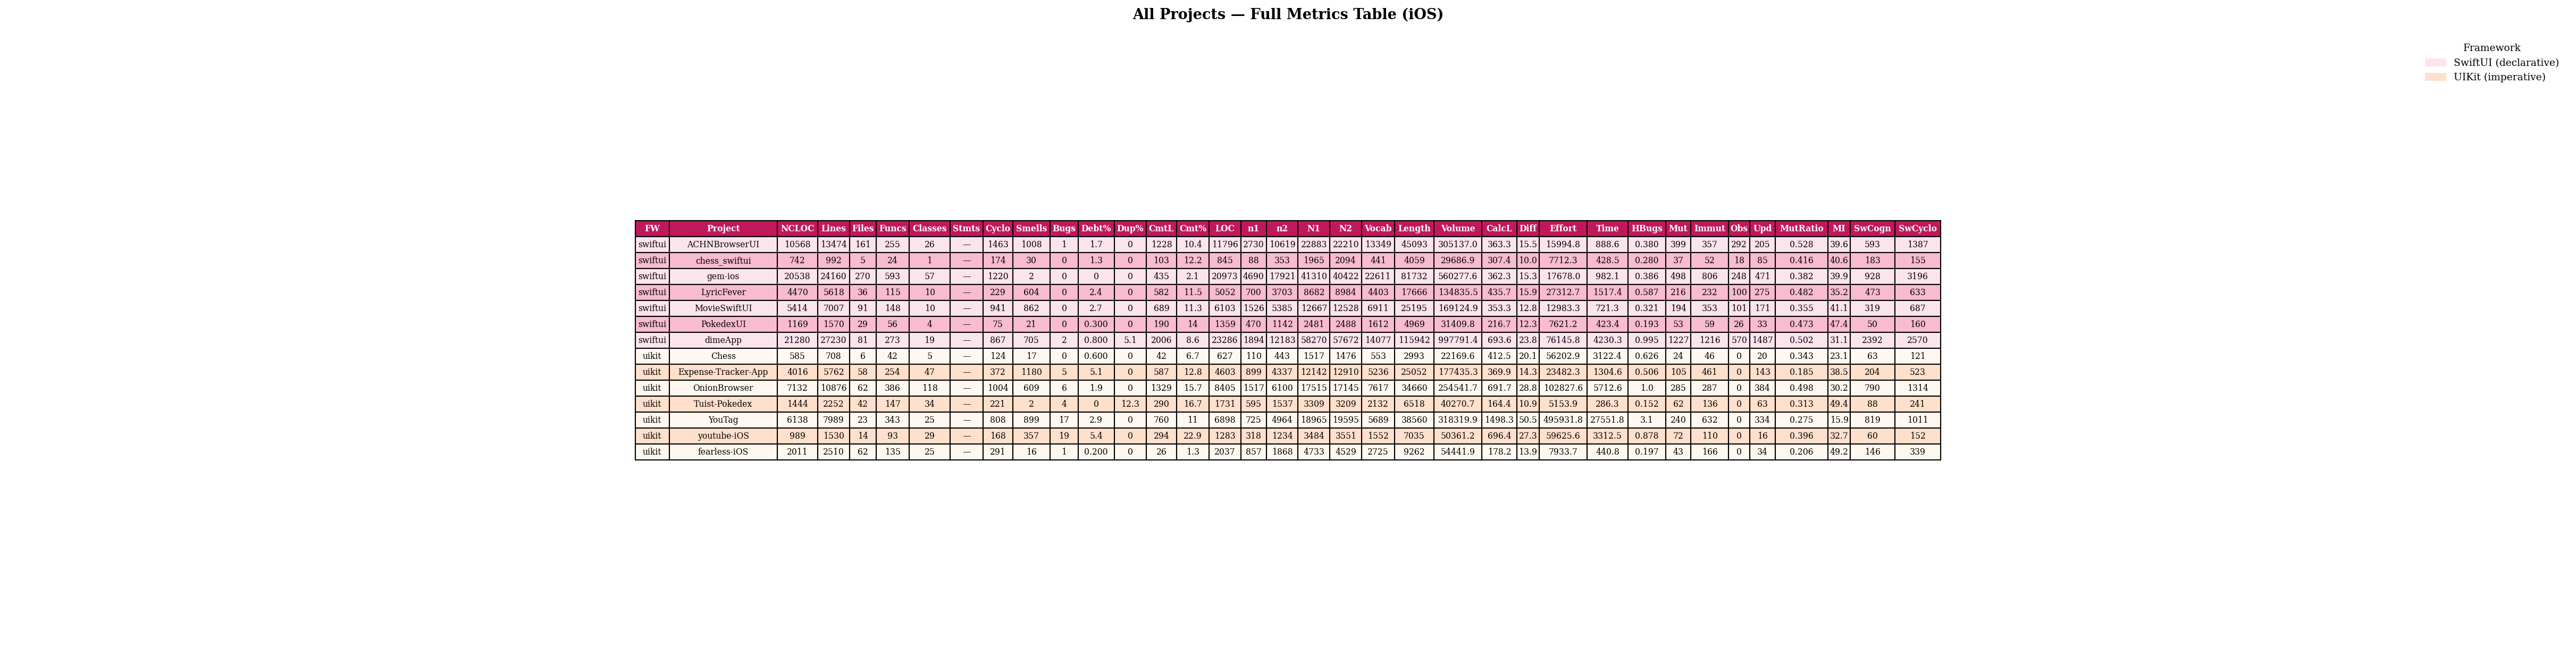

In [10]:
SHORT_NAMES = {
    'framework': 'FW', 'project': 'Project',
    'sq_ncloc': 'NCLOC', 'sq_lines': 'Lines', 'sq_files': 'Files',
    'sq_functions': 'Funcs', 'sq_classes': 'Classes', 'sq_statements': 'Stmts',
    'sq_complexity': 'Cyclo',
    'sq_code_smells': 'Smells', 'sq_bugs': 'Bugs', 'sq_sqale_debt_ratio': 'Debt%',
    'sq_duplicated_lines_density': 'Dup%', 'sq_comment_lines': 'CmtL',
    'sq_comment_lines_density': 'Cmt%',
    'hal_loc': 'LOC', 'hal_n1_unique_operators': 'n1', 'hal_n2_unique_operands': 'n2',
    'hal_N1_total_operators': 'N1', 'hal_N2_total_operands': 'N2',
    'hal_vocabulary': 'Vocab', 'hal_length': 'Length', 'hal_volume': 'Volume',
    'hal_calculated_length': 'CalcL', 'hal_difficulty': 'Diff',
    'hal_effort': 'Effort', 'hal_time_seconds': 'Time', 'hal_bugs_delivered': 'HBugs',
    'state_mutable_vars': 'Mut', 'state_immutable_vars': 'Immut',
    'state_observable_state_vars': 'Obs', 'state_state_updates': 'Upd',
    'derived_mutable_variable_ratio': 'MutRatio', 'derived_maintainability_index': 'MI',
    'swift_total_cognitive': 'SwCogn', 'swift_total_cyclomatic': 'SwCyclo',
}

HEADER_PINK    = '#C2185B'   # deep pink — header row
SWIFTUI_PINK   = '#FCE4EC'   # light pink — swiftui rows
SWIFTUI_PINK2  = '#F8BBD0'   # slightly darker pink — swiftui alternating
UIKIT_CREAM    = '#FFF8F0'   # near-white cream — uikit rows
UIKIT_CREAM2   = '#FFE0CC'   # light peach — uikit alternating

df_plot = df.reset_index()

def fmt_val(v):
    if pd.isna(v):
        return '—'
    if isinstance(v, float) and v == int(v) and abs(v) < 1e9:
        return str(int(v))
    if isinstance(v, float) and abs(v) < 1:
        return f'{v:.3f}'
    if isinstance(v, float):
        return f'{v:.1f}'
    return str(v)

col_labels = [SHORT_NAMES.get(c, c) for c in df_plot.columns]
cell_text  = [[fmt_val(v) for v in row] for row in df_plot.itertuples(index=False)]

# Row colors: alternate within each framework group
cell_colors = []
swiftui_idx = 0
uikit_idx   = 0
for _, row in df_plot.iterrows():
    if row['framework'] == 'swiftui':
        color = SWIFTUI_PINK if swiftui_idx % 2 == 0 else SWIFTUI_PINK2
        swiftui_idx += 1
    else:
        color = UIKIT_CREAM if uikit_idx % 2 == 0 else UIKIT_CREAM2
        uikit_idx += 1
    cell_colors.append([color] * len(col_labels))

n_cols = len(col_labels)
n_rows = len(cell_text)
fig_w  = max(22, n_cols * 0.9)
fig_h  = max(6,  n_rows * 0.45 + 2.0)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width(col=list(range(n_cols)))

for j in range(n_cols):
    tbl[0, j].set_facecolor(HEADER_PINK)
    tbl[0, j].set_text_props(color='white', fontweight='bold')

swiftui_patch = mpatches.Patch(color=SWIFTUI_PINK,  label='SwiftUI (declarative)')
uikit_patch   = mpatches.Patch(color=UIKIT_CREAM2,  label='UIKit (imperative)')
ax.legend(handles=[swiftui_patch, uikit_patch], fontsize=9,
          loc='upper right', title='Framework', title_fontsize=9)

ax.set_title('All Projects — Full Metrics Table (iOS)', fontsize=13, fontweight='bold', pad=14)
fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'full_metrics_table_ios.png', dpi=200, bbox_inches='tight')
plt.show()

---
# Plots

In [11]:
def build_plot_order(pairs, df):
    order, tick_labels, bar_colors, bg_spans = [], [], [], []
    x = 0
    for fw_a, proj_a, color_a, fw_b, proj_b, color_b, bg_color in pairs:
        group_start = x
        if (fw_a, proj_a) in df.index:
            order.append((fw_a, proj_a))
            tick_labels.append(proj_a)
            bar_colors.append(color_a)
            x += 1
        if fw_b is not None and (fw_b, proj_b) in df.index:
            order.append((fw_b, proj_b))
            tick_labels.append(proj_b)
            bar_colors.append(color_b)
            x += 1
        if x > group_start:
            bg_spans.append((group_start - 0.5, x - 0.5, bg_color))
    return order, tick_labels, bar_colors, bg_spans


def paired_bar(ax, col, ylabel, title, pairs, df, log=False):
    order, tick_labels, bar_colors, bg_spans = build_plot_order(pairs, df)
    values = [df.loc[key, col] if key in df.index else np.nan for key in order]

    for x0, x1, color in bg_spans:
        ax.axvspan(x0, x1, color=color, alpha=0.35, zorder=0)

    ax.bar(range(len(order)), values, color=bar_colors, zorder=3, width=0.6)

    for x0, x1, color in bg_spans:
        ax.axvspan(x0, x1, color=color, alpha=0.2, zorder=4)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(tick_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if log:
        ax.set_yscale('log')

    ax.legend(handles=[
        mpatches.Patch(color=COLORS['uikit'],   label='UIKit'),
        mpatches.Patch(color=COLORS['swiftui'], label='SwiftUI'),
    ], fontsize=8)


print('Helper functions ready.')

Helper functions ready.


### SonarQube — complexity & size

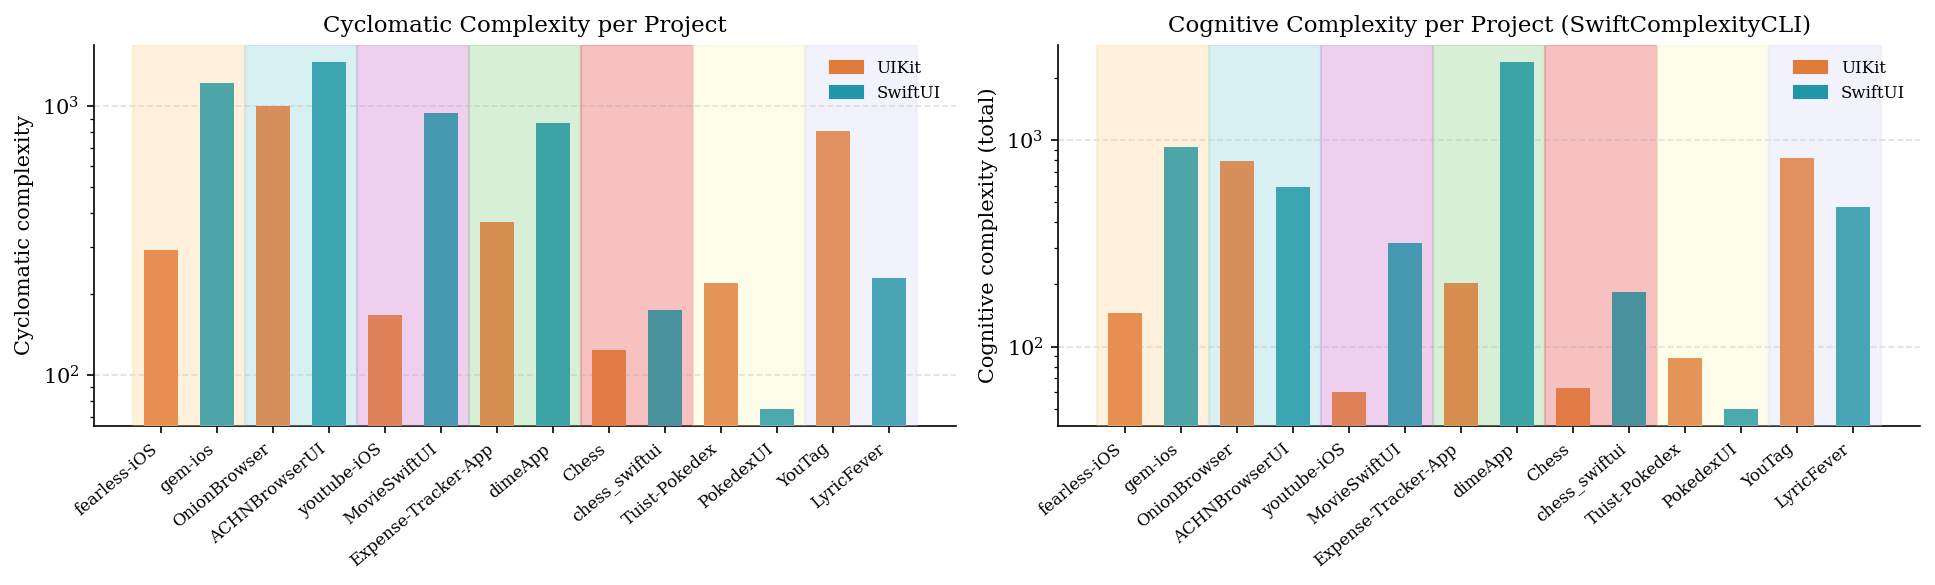

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'sq_complexity',
           ylabel='Cyclomatic complexity',
           title='Cyclomatic Complexity per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'swift_total_cognitive',
           ylabel='Cognitive complexity (total)',
           title='Cognitive Complexity per Project (SwiftComplexityCLI)',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_complexity.pdf')
plt.show()

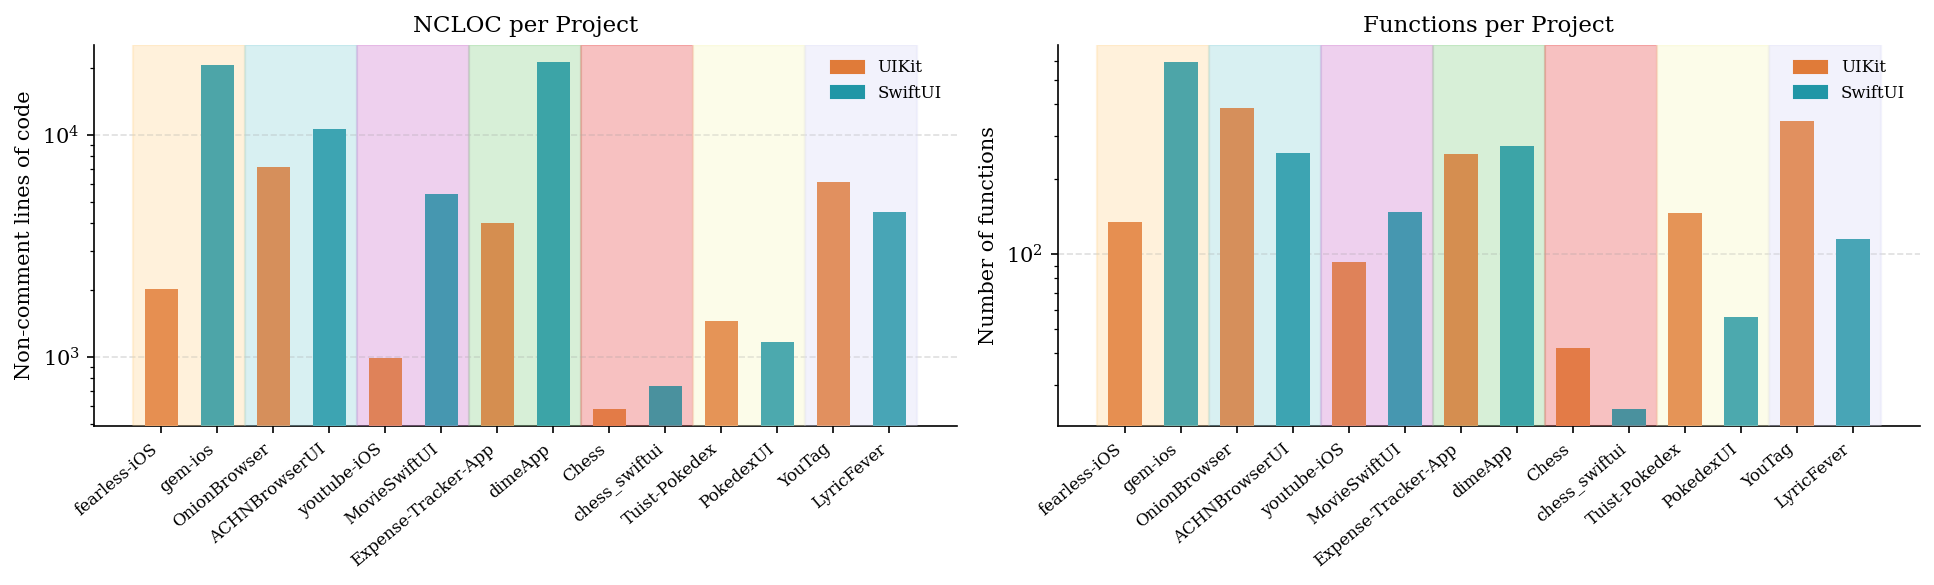

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'sq_ncloc',
           ylabel='Non-comment lines of code',
           title='NCLOC per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_functions',
           ylabel='Number of functions',
           title='Functions per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_size.pdf')
plt.show()

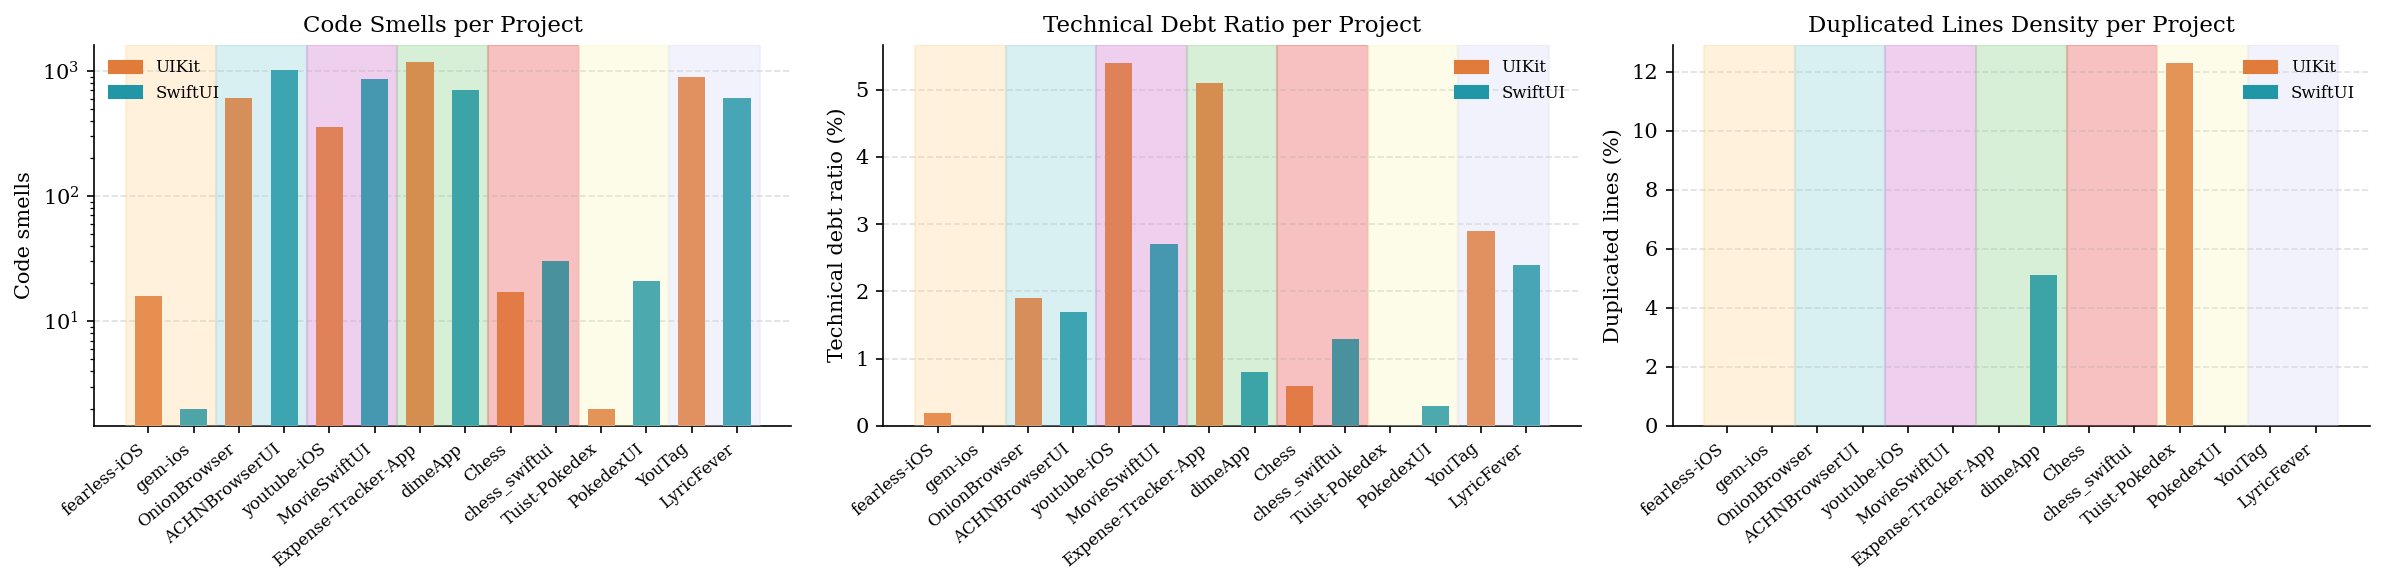

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paired_bar(axes[0], 'sq_code_smells',
           ylabel='Code smells',
           title='Code Smells per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'sq_sqale_debt_ratio',
           ylabel='Technical debt ratio (%)',
           title='Technical Debt Ratio per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[2], 'sq_duplicated_lines_density',
           ylabel='Duplicated lines (%)',
           title='Duplicated Lines Density per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_quality.pdf')
plt.show()

### Halstead metrics

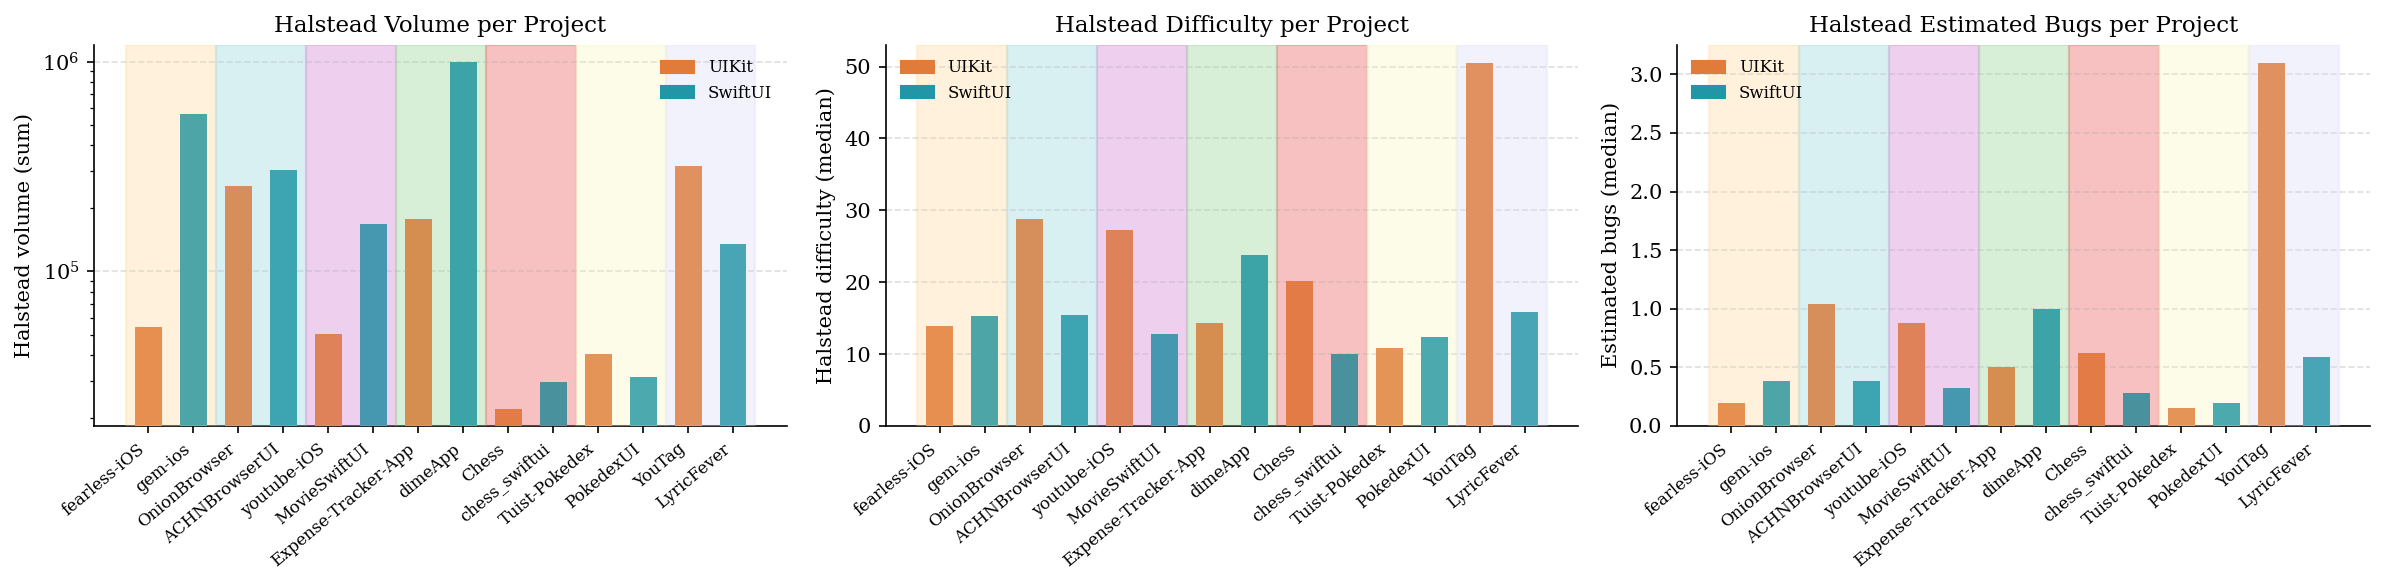

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paired_bar(axes[0], 'hal_volume',
           ylabel='Halstead volume (sum)',
           title='Halstead Volume per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'hal_difficulty',
           ylabel='Halstead difficulty (median)',
           title='Halstead Difficulty per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[2], 'hal_bugs_delivered',
           ylabel='Estimated bugs (median)',
           title='Halstead Estimated Bugs per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_halstead.pdf')
plt.show()

### State metrics

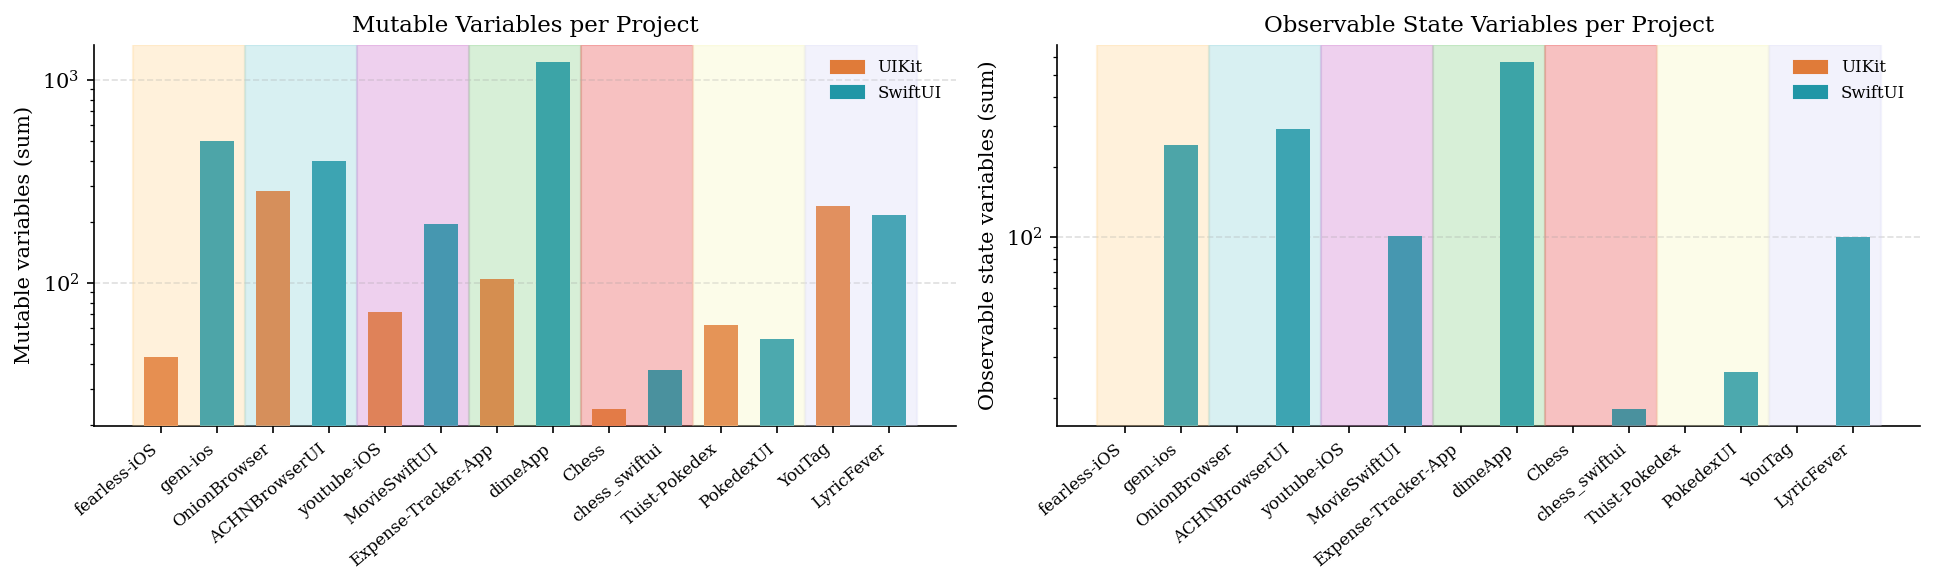

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'state_mutable_vars',
           ylabel='Mutable variables (sum)',
           title='Mutable Variables per Project',
           pairs=PAIRS, df=df, log=True)

paired_bar(axes[1], 'state_observable_state_vars',
           ylabel='Observable state variables (sum)',
           title='Observable State Variables per Project',
           pairs=PAIRS, df=df, log=True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_state.pdf')
plt.show()

### Derived metrics

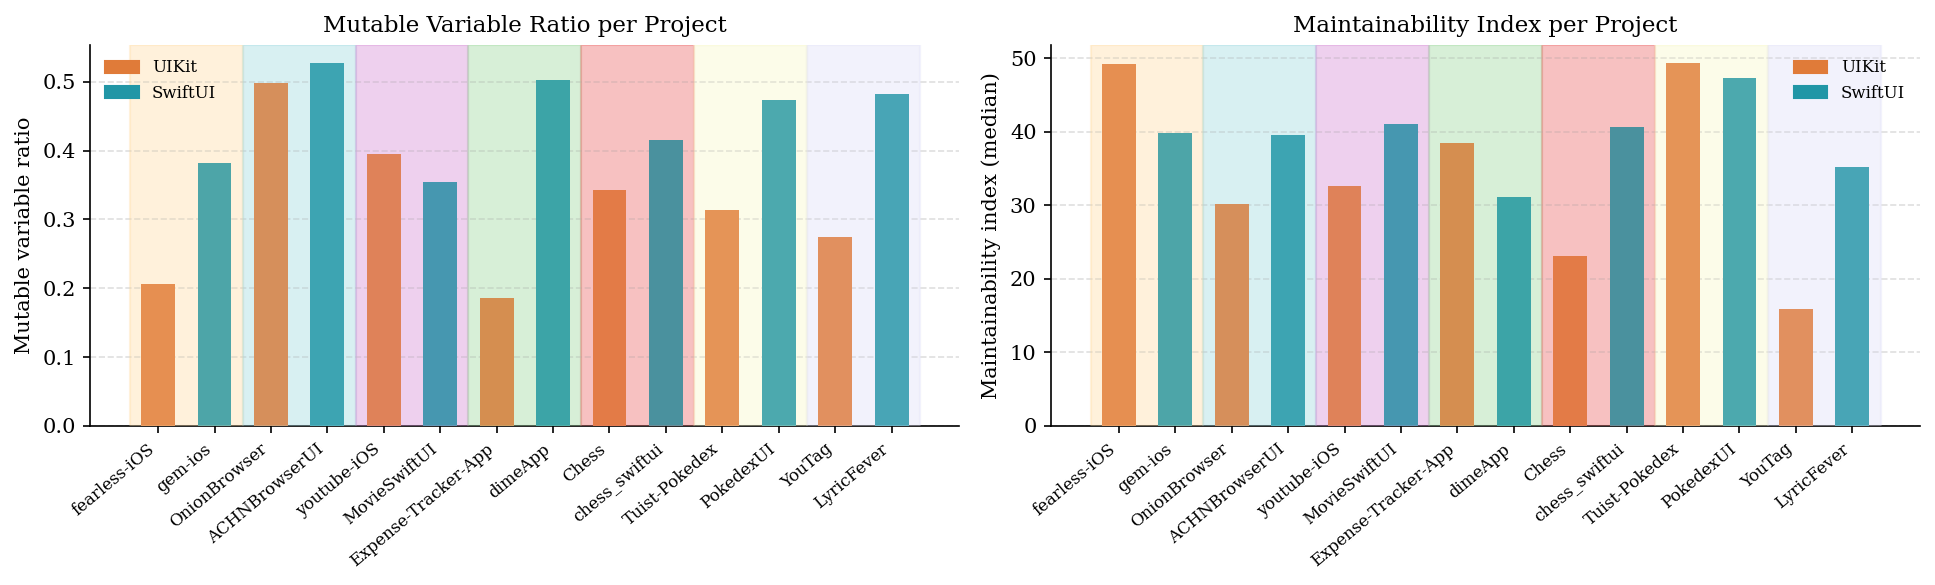

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

paired_bar(axes[0], 'derived_mutable_variable_ratio',
           ylabel='Mutable variable ratio',
           title='Mutable Variable Ratio per Project',
           pairs=PAIRS, df=df)

paired_bar(axes[1], 'derived_maintainability_index',
           ylabel='Maintainability index (median)',
           title='Maintainability Index per Project',
           pairs=PAIRS, df=df)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_derived.pdf')
plt.show()

## Export to CSV

In [18]:
out_path = RESULTS_DIR / 'metrics_table_ios.csv'
df.to_csv(out_path)
print(f'Saved to {out_path}')

Saved to ../results/metrics_table_ios.csv


## Statistical Analysis — Paired Wilcoxon Tests

In [19]:
from scipy import stats as scipy_stats

METRIC_CATEGORIES = {
    'Structural': [
        'sq_complexity', 'swift_total_cognitive',
        'sq_code_smells', 'sq_bugs', 'sq_sqale_debt_ratio',
        'sq_duplicated_lines_density', 'derived_maintainability_index',
        'hal_vocabulary', 'hal_length', 'hal_volume', 'hal_calculated_length',
        'hal_difficulty', 'hal_effort', 'hal_bugs_delivered',
    ],
    'Size-based': [
        'sq_ncloc', 'sq_lines', 'sq_files', 'sq_statements',
        'sq_comment_lines', 'sq_comment_lines_density',
        'sq_functions', 'sq_classes',
    ],
    'State-related': [
        'state_mutable_vars', 'state_immutable_vars',
        'state_observable_state_vars', 'state_state_updates',
        'derived_mutable_variable_ratio',
    ],
}

METRIC_LABELS = {
    'sq_complexity':               'SwCyC',
    'swift_total_cognitive':       'SwCoC',
    'sq_code_smells':              'Smells',
    'sq_bugs':                     'Bugs',
    'sq_sqale_debt_ratio':         'Debt%',
    'sq_duplicated_lines_density': 'Dupl%',
    'derived_maintainability_index': 'MI',
    'hal_vocabulary':              'Vocab',
    'hal_length':                  'Length',
    'hal_volume':                  'Volume',
    'hal_calculated_length':       'CalcL',
    'hal_difficulty':              'Diff',
    'hal_effort':                  'Effort',
    'hal_bugs_delivered':          'HBugs',
    'sq_ncloc':                    'NCLOC',
    'sq_lines':                    'LoC',
    'sq_files':                    'Files',
    'sq_statements':               'Stmts',
    'sq_comment_lines':            'CmtL',
    'sq_comment_lines_density':    'Cmt%',
    'sq_functions':                'Funcs',
    'sq_classes':                  'Classes',
    'state_mutable_vars':          'Mut',
    'state_immutable_vars':        'Immut',
    'state_observable_state_vars': 'Obs',
    'state_state_updates':         'Upd',
    'derived_mutable_variable_ratio': 'MutRatio',
}


def get_paired_values(metric):
    """Return (uikit_vals, swiftui_vals, pair_labels) aligned by pair order."""
    a_vals, b_vals, labels = [], [], []
    for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
        idx_a = (fw_a, proj_a)
        idx_b = (fw_b, proj_b) if fw_b else None
        if idx_a not in df.index or idx_b not in df.index:
            continue
        va = df.loc[idx_a, metric]
        vb = df.loc[idx_b, metric]
        if pd.isna(va) or pd.isna(vb):
            continue
        a_vals.append(float(va))
        b_vals.append(float(vb))
        labels.append(f'{proj_a} vs {proj_b}')
    return np.array(a_vals), np.array(b_vals), labels


def wilcoxon_test(a_vals, b_vals):
    if len(a_vals) < 3:
        return None, None, None
    diffs = a_vals - b_vals
    if np.all(diffs == 0):
        return 1.0, 0.0, 'negligible'
    try:
        stat, p = scipy_stats.wilcoxon(a_vals, b_vals, alternative='two-sided')
    except ValueError:
        return None, None, None
    n = len(a_vals)
    r = 1 - (2 * stat) / (n * (n + 1) / 2)
    magnitude = 'large' if abs(r) >= 0.5 else ('medium' if abs(r) >= 0.3 else ('small' if abs(r) >= 0.1 else 'negligible'))
    return p, r, magnitude


results = []
for category, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df.columns:
            continue
        a_vals, b_vals, _ = get_paired_values(metric)
        if len(a_vals) == 0:
            continue
        uikit_mean   = np.mean(a_vals)
        uikit_std    = np.std(a_vals, ddof=1)
        swiftui_mean = np.mean(b_vals)
        swiftui_std  = np.std(b_vals, ddof=1)
        p, r, mag    = wilcoxon_test(a_vals, b_vals)
        results.append({
            'category':      category,
            'metric':        metric,
            'uikit_mean':    uikit_mean,
            'uikit_std':     uikit_std,
            'swiftui_mean':  swiftui_mean,
            'swiftui_std':   swiftui_std,
            'p_value':       p,
            'effect_r':      r,
            'effect_size':   mag,
            'n_pairs':       len(a_vals),
        })

stats_df = pd.DataFrame(results)
print(f'{len(stats_df)} metrics tested across {len(METRIC_CATEGORIES)} categories')

26 metrics tested across 3 categories


### Results table

UIKit = imperative side, SwiftUI = declarative side.  
p < 0.05 = statistically significant difference.  
Effect size r: negligible < 0.1, small 0.1–0.3, medium 0.3–0.5, large > 0.5.

In [20]:
def fmt_mean_std(mean, std):
    if pd.isna(mean): return '—'
    return f'{mean:.1f} ± {std:.1f}'

def fmt_p(p):
    if p is None or pd.isna(p): return '—'
    if p < 0.001: return '< 0.001 ***'
    if p < 0.01:  return f'{p:.3f} **'
    if p < 0.05:  return f'{p:.3f} *'
    return f'{p:.3f}'

display_rows = []
for _, row in stats_df.iterrows():
    p = row['p_value']
    significant = (p is not None) and (not pd.isna(p)) and (p < 0.05)
    display_rows.append({
        'Dimension':           row['category'],
        'Metric':             METRIC_LABELS.get(row['metric'], row['metric']),
        'UIKit (mean±sd)':    fmt_mean_std(row['uikit_mean'],   row['uikit_std']),
        'SwiftUI (mean±sd)':  fmt_mean_std(row['swiftui_mean'], row['swiftui_std']),
        'p-value':            fmt_p(p),
        'r':                  f"{row['effect_r']:.2f}" if row['effect_r'] is not None and not pd.isna(row['effect_r']) else '—',
        'Effect':             row['effect_size'] if row['effect_size'] else '—',
        'Significant':        'Yes' if significant else 'No',
    })

display_df = pd.DataFrame(display_rows).set_index(['Dimension', 'Metric'])
display_df

UIKit (mean±sd)    SwiftUI (mean±sd)  p-value  \
Dimension     Metric                                                        
Structural    SwCyC           426.9 ± 341.8        709.9 ± 551.8    0.297   
              SwCoC           310.0 ± 341.7        705.4 ± 797.1    0.469   
              Smells          440.0 ± 473.3        461.7 ± 434.0    0.812   
              Bugs                7.4 ± 7.5            0.4 ± 0.8  0.031 *   
              Debt%               2.3 ± 2.3            1.3 ± 1.0    0.375   
              Dupl%               1.8 ± 4.6            0.7 ± 1.9    1.000   
              MI                34.1 ± 12.6           39.3 ± 5.1    0.297   
              Vocab         3643.4 ± 2567.8      9057.7 ± 7992.3    0.219   
              Length      17725.7 ± 14737.2    42093.7 ± 42310.2    0.297   
              Volume    131077.2 ± 118986.8  318323.3 ± 351651.1    0.297   
              CalcL           573.1 ± 461.0        390.3 ± 149.4    0.375   
              Diff              23.7 ± 13.7           15.1 ± 4.4    0.219   
              Effort    107308.3 ± 174771.9    23635.4 ± 24111.6    0.375   
              HBugs               0.9 ± 1.0            0.4 ± 0.3    0.297   
Size-based    NCLOC         3187.9 ± 2613.5      9168.7 ± 8651.4    0.156   
              LoC           4518.1 ± 3799.8    11435.9 ± 10609.6    0.156   
              Files             38.1 ± 23.8          96.1 ± 92.3    0.094   
              CmtL            475.4 ± 461.7        747.6 ± 667.0    0.469   
              Cmt%               12.4 ± 7.0           10.0 ± 3.9    0.469   
              Funcs           200.0 ± 130.0        209.1 ± 193.2    0.812   
              Classes           40.4 ± 36.4          18.1 ± 19.1    0.219   
State-related Mut             118.7 ± 102.2        374.9 ± 411.8    0.109   
              Immut           262.6 ± 212.9        439.3 ± 426.1    0.375   
              Obs                 0.0 ± 0.0        193.6 ± 196.0  0.016 *   
              Upd             142.0 ± 155.0        389.6 ± 504.3    0.375   
              MutRatio            0.3 ± 0.1            0.4 ± 0.1  0.047 *   

                           r  Effect Significant  
Dimension     Metric                              
Structural    SwCyC     0.50   large          No  
              SwCoC     0.36  medium          No  
              Smells    0.14   small          No  
              Bugs      1.00   large         Yes  
              Debt%     0.43  medium          No  
              Dupl%     0.93   large          No  
              MI        0.50   large          No  
              Vocab     0.57   large          No  
              Length    0.50   large          No  
              Volume    0.50   large          No  
              CalcL     0.43  medium          No  
              Diff      0.57   large          No  
              Effort    0.43  medium          No  
              HBugs     0.50   large          No  
Size-based    NCLOC     0.64   large          No  
              LoC       0.64   large          No  
              Files     0.75   large          No  
              CmtL      0.36  medium          No  
              Cmt%      0.36  medium          No  
              Funcs     0.14   small          No  
              Classes   0.57   large          No  
State-related Mut       0.71   large          No  
              Immut     0.43  medium          No  
              Obs       1.00   large         Yes  
              Upd       0.43  medium          No  
              MutRatio  0.86   large         Yes

### Statistics table — thesis figure

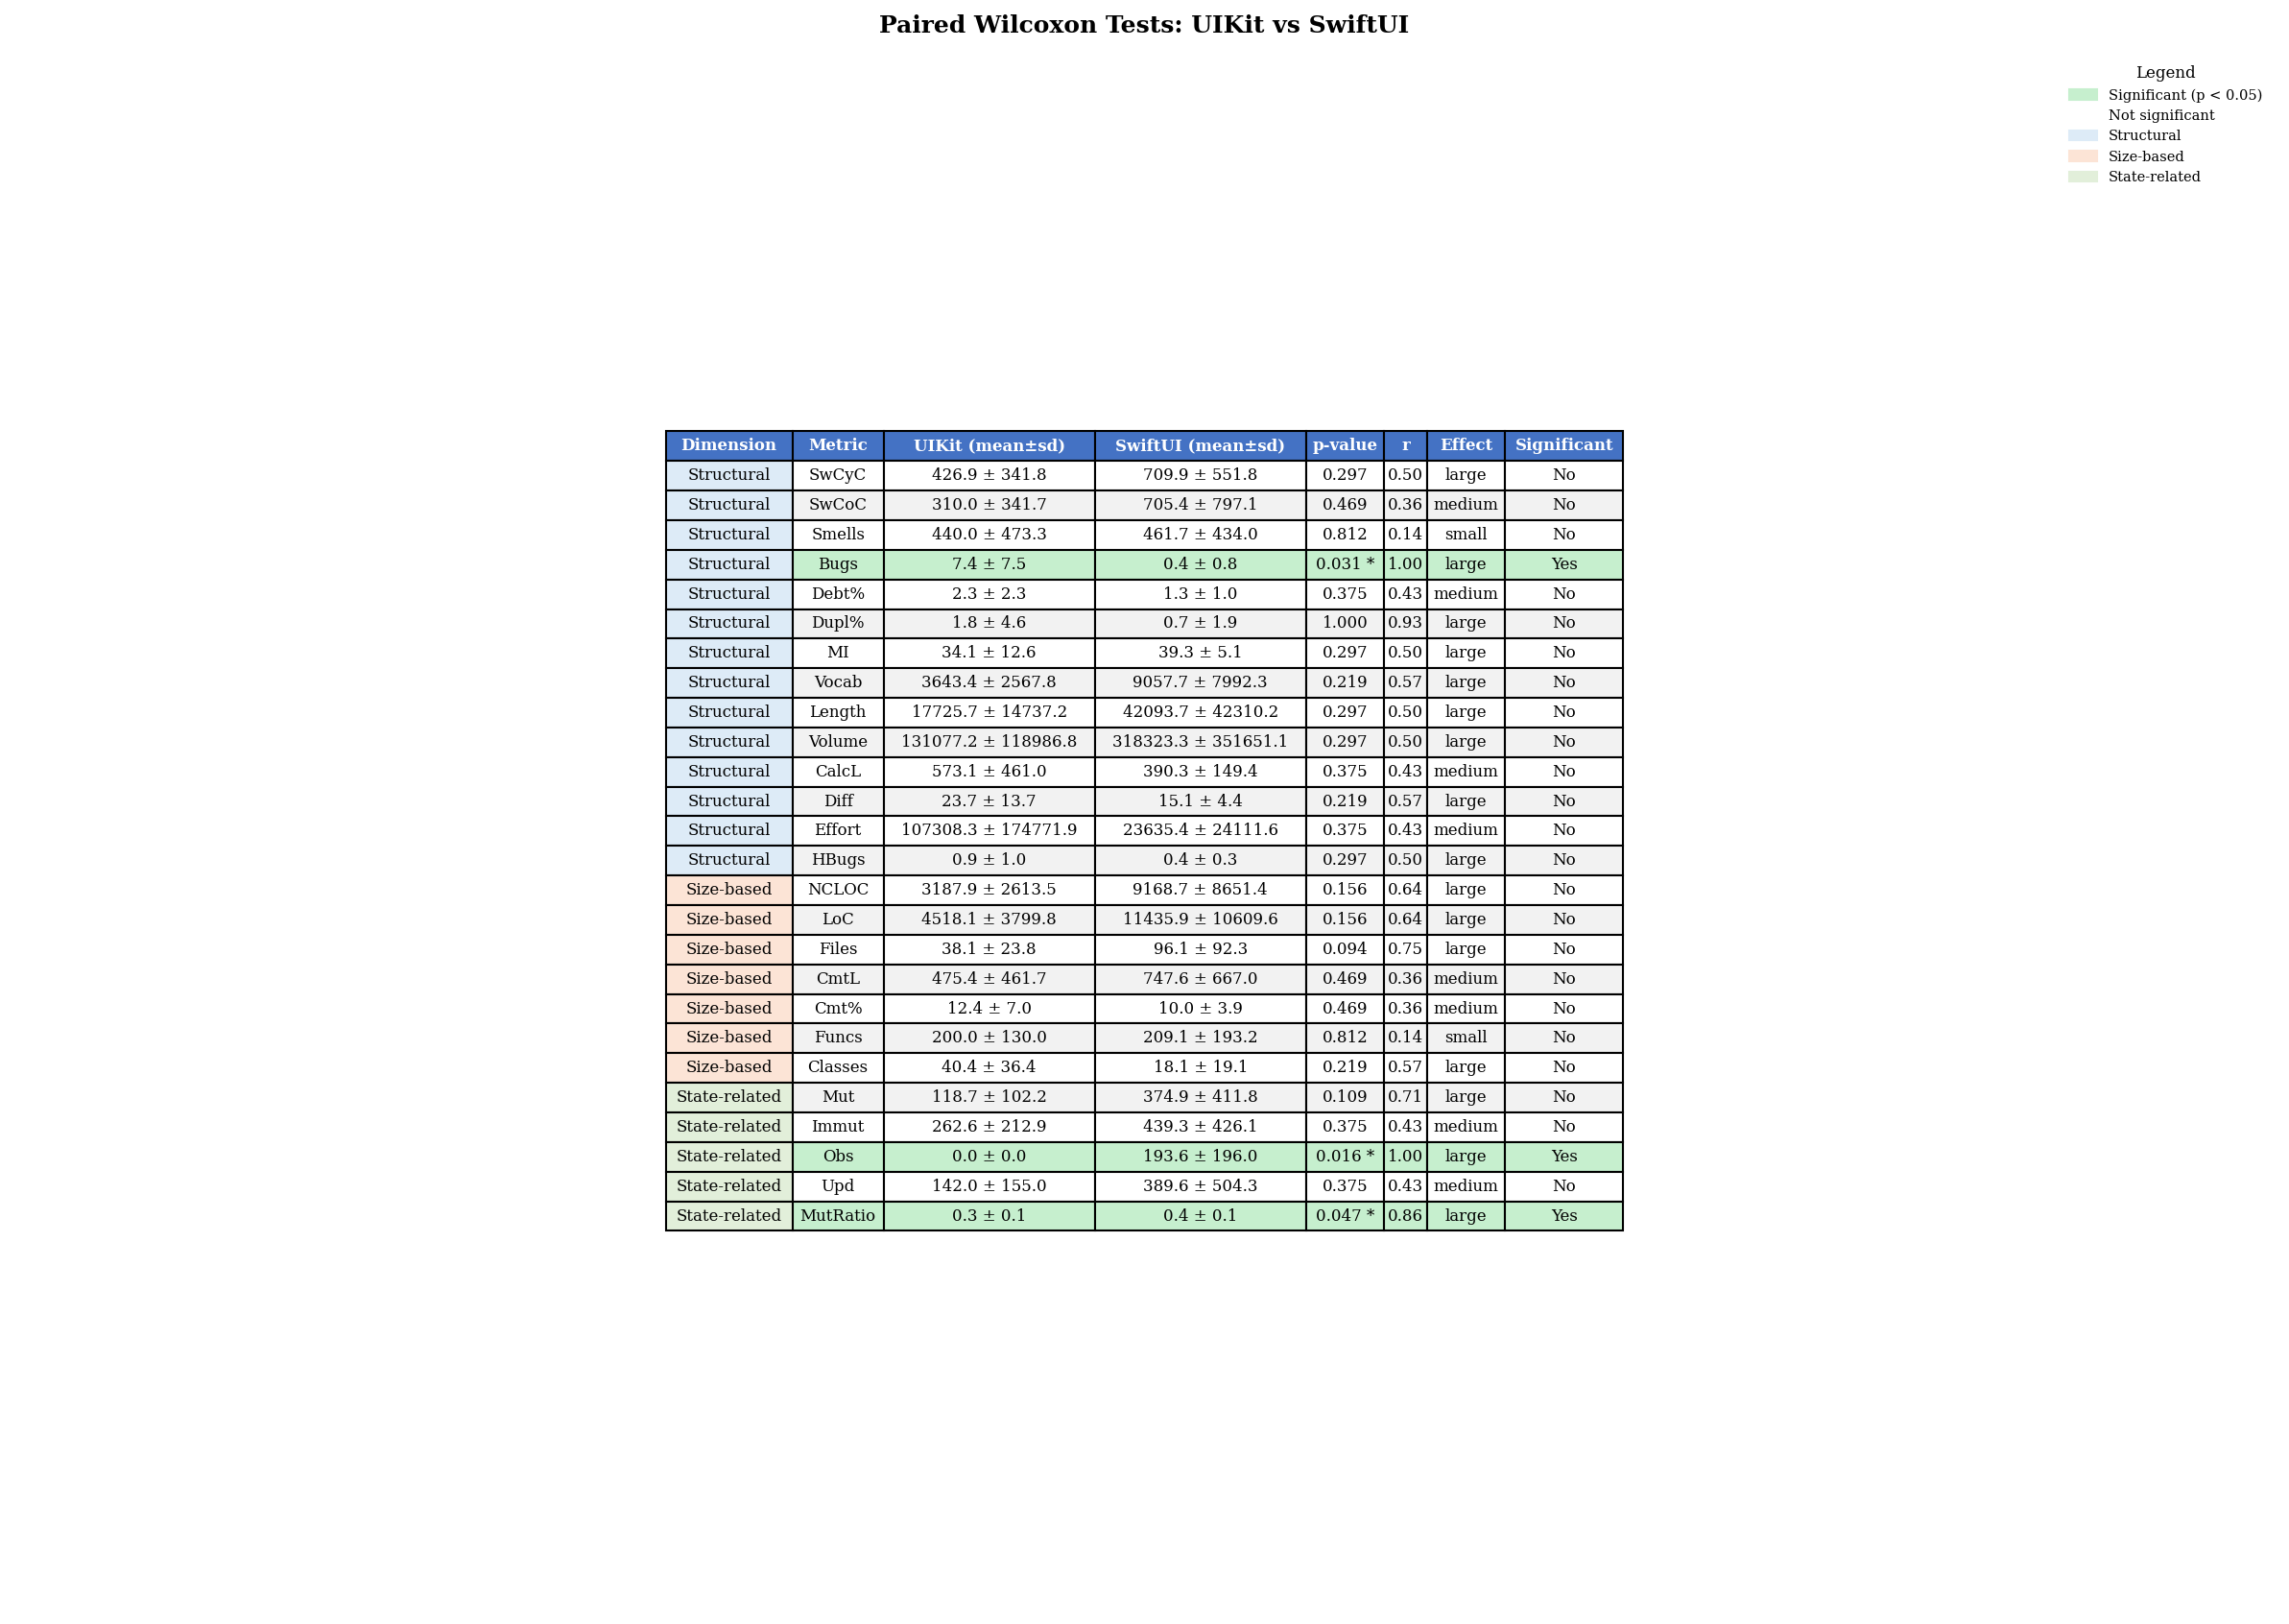

In [21]:
HEADER_COLOR = '#4472C4'
SIG_COLOR    = '#C6EFCE'
NONSIG_COLOR = '#FFFFFF'
ALT_COLOR    = '#F2F2F2'
CAT_COLORS = {
    'Structural':    '#DDEBF7',
    'Size-based':    '#FCE4D6',
    'State-related': '#E2EFDA',
}

cols = ['UIKit (mean±sd)', 'SwiftUI (mean±sd)', 'p-value', 'r', 'Effect', 'Significant']
table_df = display_df.reset_index()

cell_text, cell_colors = [], []
col_headers = ['Dimension', 'Metric'] + cols

for i, row in table_df.iterrows():
    text_row  = [row['Dimension'], row['Metric']] + [str(row[c]) for c in cols]
    sig       = row['Significant'] == 'Yes'
    base_col  = SIG_COLOR if sig else (NONSIG_COLOR if i % 2 == 0 else ALT_COLOR)
    cat_col   = CAT_COLORS.get(row['Dimension'], '#FFFFFF')
    color_row = [cat_col, base_col] + [base_col] * len(cols)
    cell_text.append(text_row)
    cell_colors.append(color_row)

n_rows = len(cell_text)
n_cols = len(col_headers)
fig_h  = max(4, n_rows * 0.38 + 1.5)
fig, ax = plt.subplots(figsize=(16, fig_h))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_headers,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(n_cols)))

for j in range(n_cols):
    tbl[0, j].set_facecolor(HEADER_COLOR)
    tbl[0, j].set_text_props(color='white', fontweight='bold')

sig_patch    = mpatches.Patch(color=SIG_COLOR,    label='Significant (p < 0.05)')
nonsig_patch = mpatches.Patch(color=NONSIG_COLOR, label='Not significant', linewidth=0.5)
cat_patches  = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax.legend(handles=[sig_patch, nonsig_patch] + cat_patches,
          loc='upper right', fontsize=7, title='Legend', title_fontsize=8)

plt.title('Paired Wilcoxon Tests: UIKit vs SwiftUI', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'ios_stats_table.png', dpi=300, bbox_inches='tight')
plt.show()

### Mean difference: Imperative − Declarative

Each bar shows `(UIKit mean − SwiftUI mean) / midpoint × 100%`.  
Bars **above zero** → UIKit (imperative) had the larger value.  
Bars **below zero** → SwiftUI (declarative) had the larger value.  
`*` marks metrics that are statistically significant (p < 0.05).

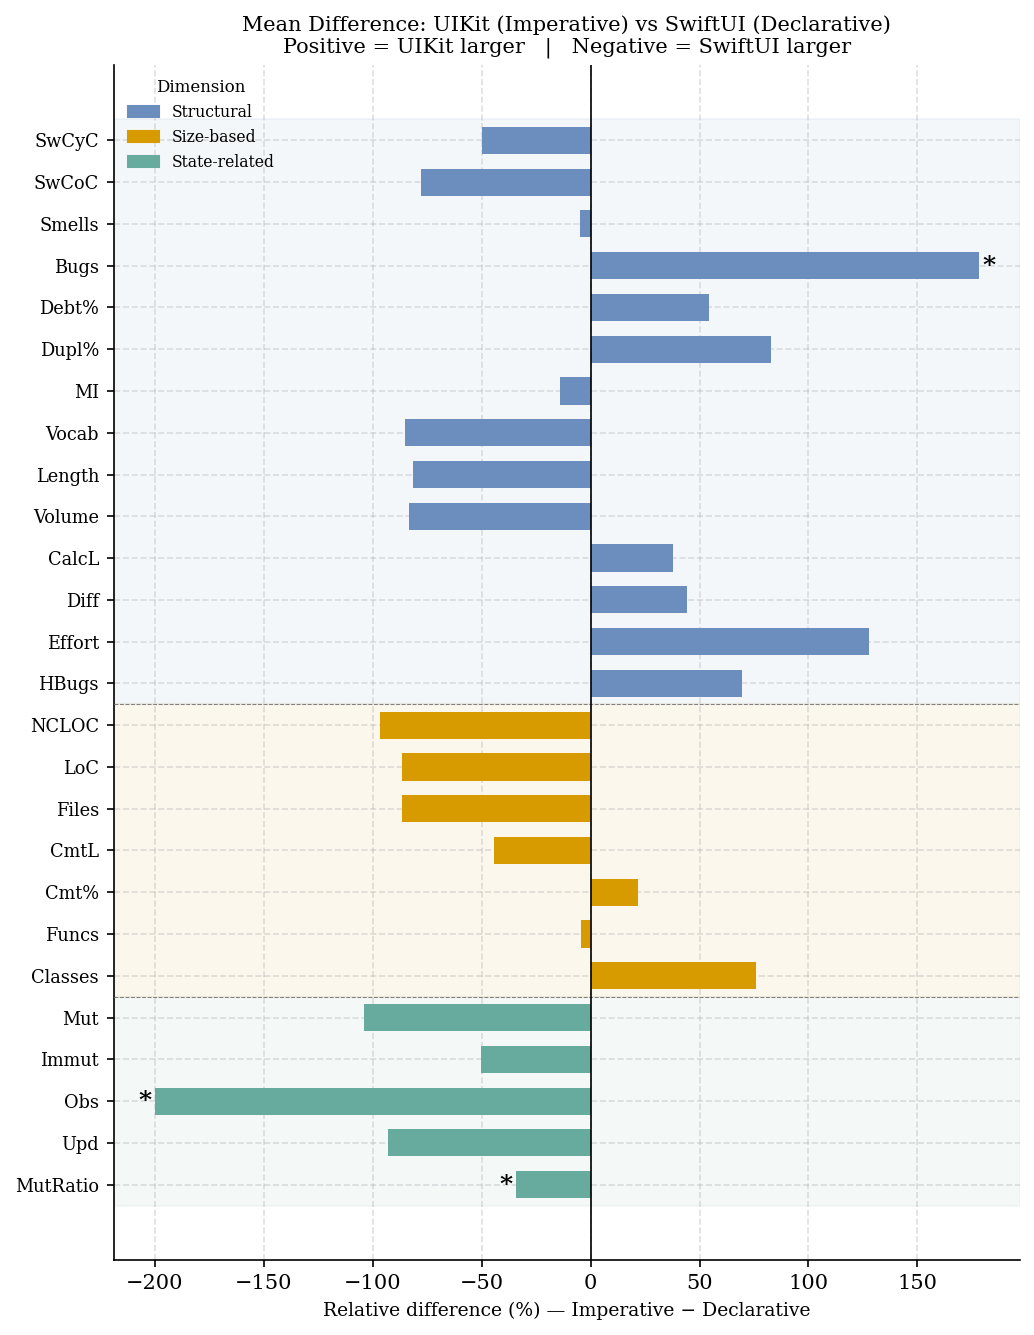

In [22]:

CAT_BAR_COLORS = {
    'Structural':    '#6C8EBF',
    'Size-based':    '#D79B00',
    'State-related': '#67AB9F',
}

category_order = ['Structural', 'Size-based', 'State-related']


def get_paired_values_raw(metric):
    a_vals, b_vals = [], []
    for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
        idx_a = (fw_a, proj_a)
        idx_b = (fw_b, proj_b)
        if idx_a not in df.index or idx_b not in df.index:
            continue
        va = df.loc[idx_a, metric]
        vb = df.loc[idx_b, metric]
        if pd.isna(va) or pd.isna(vb):
            continue
        a_vals.append(float(va))
        b_vals.append(float(vb))
    return np.array(a_vals), np.array(b_vals)


plot_rows = []
for cat, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df.columns:
            continue
        a_vals, b_vals = get_paired_values_raw(metric)
        if len(a_vals) == 0:
            continue
        uikit_mean   = np.mean(a_vals)
        swiftui_mean = np.mean(b_vals)
        midpoint     = (uikit_mean + swiftui_mean) / 2
        diff_pct     = (uikit_mean - swiftui_mean) / midpoint * 100 if midpoint != 0 else 0.0

        row_stats = stats_df[stats_df['metric'] == metric]
        p_value   = row_stats['p_value'].values[0] if len(row_stats) else None

        plot_rows.append({
            'category': cat,
            'metric':   metric,
            'diff_pct': diff_pct,
            'p_value':  p_value,
        })

cat_rank = {c: i for i, c in enumerate(category_order)}
plot_rows.sort(key=lambda r: (cat_rank.get(r['category'], 99),
                               list(METRIC_CATEGORIES.get(r['category'], [])).index(r['metric'])
                               if r['metric'] in METRIC_CATEGORIES.get(r['category'], []) else 99))

labels    = [METRIC_LABELS.get(r['metric'], r['metric']) for r in plot_rows]
values    = [r['diff_pct'] for r in plot_rows]
colors    = [CAT_BAR_COLORS[r['category']] for r in plot_rows]
sig_flags = [r['p_value'] is not None and not pd.isna(r['p_value']) and r['p_value'] < 0.05
             for r in plot_rows]

fig, ax = plt.subplots(figsize=(7, 9))

ax.barh(range(len(labels)), values, color=colors, height=0.65, zorder=3)

for i, (val, sig) in enumerate(zip(values, sig_flags)):
    if sig:
        x_offset = 1.5 if val >= 0 else -1.5
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + x_offset, i, '*', va='center', ha=ha,
                fontsize=12, fontweight='bold', color='black')

ax.axvline(0, color='black', linewidth=0.8, zorder=5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel('Relative difference (%) — Imperative − Declarative', fontsize=9)
ax.set_title('Mean Difference: UIKit (Imperative) vs SwiftUI (Declarative)\n'
             'Positive = UIKit larger   |   Negative = SwiftUI larger',
             fontsize=10)

cat_sizes   = [sum(1 for r in plot_rows if r['category'] == c) for c in category_order]
cat_patches = [mpatches.Patch(color=CAT_BAR_COLORS[c], label=c) for c in category_order]
sig_marker  = mpatches.Patch(color='none', label='* p < 0.05')
ax.legend(handles=cat_patches , fontsize=7.5,
          loc='upper left', title='Dimension', title_fontsize=8)

sep = 0
for size in cat_sizes[:-1]:
    sep += size
    ax.axhline(sep - 0.5, color='grey', linewidth=0.5, linestyle='--', zorder=4)

sep = 0
for cat, size in zip(category_order, cat_sizes):
    ax.axhspan(sep - 0.5, sep + size - 0.5,
               color=CAT_BAR_COLORS[cat], alpha=0.07, zorder=0)
    sep += size

ax.grid(True, axis='x', alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_mean_difference.pdf')
plt.show()

---
## Statistical Analysis — LOC-Normalized (per NCLOC)

Same paired Wilcoxon tests and mean-difference plot as above, but each project's count-based metric is divided by its NCLOC before comparison.  
Ratio and index metrics (`sq_sqale_debt_ratio`, `sq_duplicated_lines_density`, `sq_comment_lines_density`, `derived_maintainability_index`, `derived_mutable_variable_ratio`, `hal_difficulty`) are left as-is since they are already size-independent.

In [23]:
# Metrics already size-independent — skip LOC normalization for these
LOC_NORMALIZE_SKIP = {
    'sq_sqale_debt_ratio', 'sq_duplicated_lines_density', 'sq_comment_lines_density',
    'derived_maintainability_index', 'derived_mutable_variable_ratio', 'hal_difficulty',
}

def get_paired_values_norm(metric, norm_col='sq_ncloc'):
    """Return paired values normalized by each project's NCLOC (skipped for ratio/index metrics)."""
    a_vals, b_vals = [], []
    for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
        idx_a = (fw_a, proj_a)
        idx_b = (fw_b, proj_b)
        if idx_a not in df.index or idx_b not in df.index:
            continue
        va = df.loc[idx_a, metric]
        vb = df.loc[idx_b, metric]
        if pd.isna(va) or pd.isna(vb):
            continue
        if metric not in LOC_NORMALIZE_SKIP:
            ncloc_a = df.loc[idx_a, norm_col]
            ncloc_b = df.loc[idx_b, norm_col]
            if pd.isna(ncloc_a) or pd.isna(ncloc_b) or ncloc_a == 0 or ncloc_b == 0:
                continue
            va = float(va) / float(ncloc_a)
            vb = float(vb) / float(ncloc_b)
        a_vals.append(float(va))
        b_vals.append(float(vb))
    return np.array(a_vals), np.array(b_vals)

results_norm = []
for category, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df.columns:
            continue
        a_vals, b_vals = get_paired_values_norm(metric)
        if len(a_vals) == 0:
            continue
        uikit_mean   = np.mean(a_vals)
        uikit_std    = np.std(a_vals, ddof=1)
        swiftui_mean = np.mean(b_vals)
        swiftui_std  = np.std(b_vals, ddof=1)
        p, r, mag    = wilcoxon_test(a_vals, b_vals)
        results_norm.append({
            'category':      category,
            'metric':        metric,
            'uikit_mean':    uikit_mean,
            'uikit_std':     uikit_std,
            'swiftui_mean':  swiftui_mean,
            'swiftui_std':   swiftui_std,
            'p_value':       p,
            'effect_r':      r,
            'effect_size':   mag,
            'n_pairs':       len(a_vals),
        })

stats_df_norm = pd.DataFrame(results_norm)
print(f'{len(stats_df_norm)} metrics tested (LOC-normalized)')

26 metrics tested (LOC-normalized)


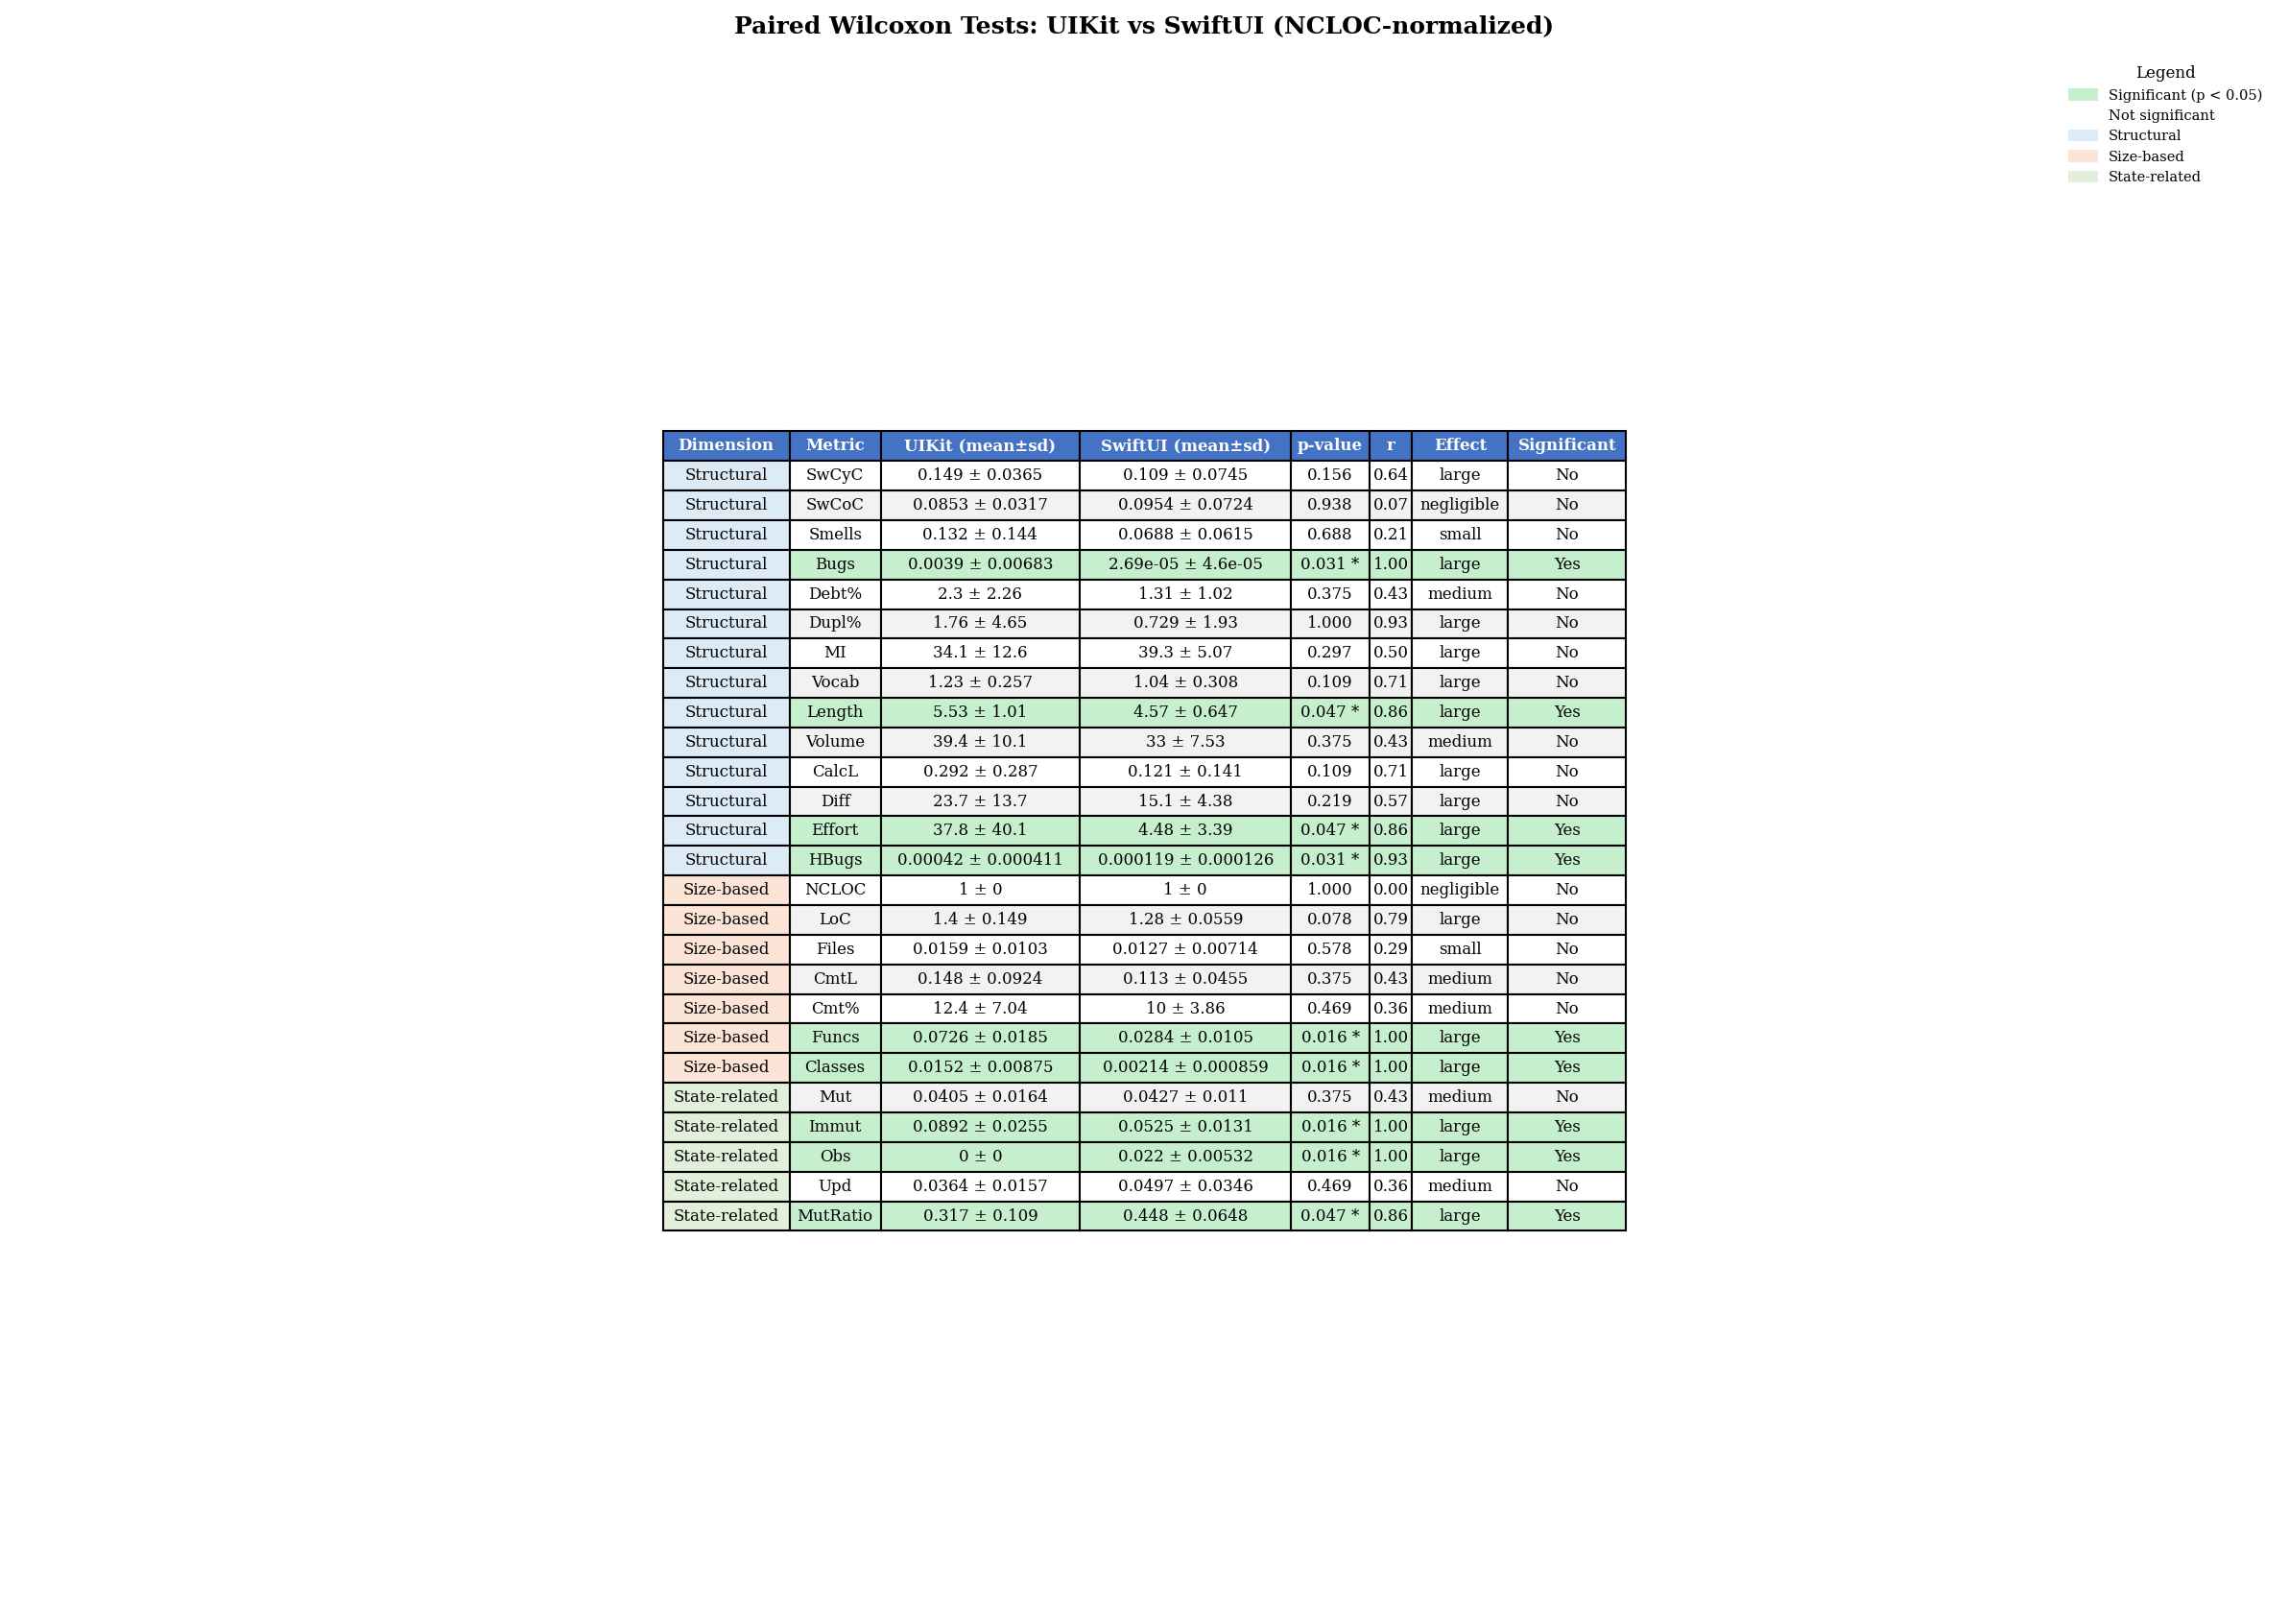

In [24]:
def fmt_mean_std_norm(mean, std):
    """Format normalized (per-NCLOC) values with 3 significant figures."""
    if pd.isna(mean):
        return '—'
    return f'{mean:.3g} ± {std:.3g}'

display_rows_norm = []
for _, row in stats_df_norm.iterrows():
    p = row['p_value']
    significant = (p is not None) and (not pd.isna(p)) and (p < 0.05)
    display_rows_norm.append({
        'Dimension':           row['category'],
        'Metric':             METRIC_LABELS.get(row['metric'], row['metric']),
        'UIKit (mean±sd)':    fmt_mean_std_norm(row['uikit_mean'],   row['uikit_std']),
        'SwiftUI (mean±sd)':  fmt_mean_std_norm(row['swiftui_mean'], row['swiftui_std']),
        'p-value':            fmt_p(p),
        'r':                  f"{row['effect_r']:.2f}" if row['effect_r'] is not None and not pd.isna(row['effect_r']) else '—',
        'Effect':             row['effect_size'] if row['effect_size'] else '—',
        'Significant':        'Yes' if significant else 'No',
    })

table_df_norm = pd.DataFrame(display_rows_norm)
cols_tbl = ['UIKit (mean±sd)', 'SwiftUI (mean±sd)', 'p-value', 'r', 'Effect', 'Significant']
col_headers_norm = ['Dimension', 'Metric'] + cols_tbl

cell_text_norm, cell_colors_norm = [], []
for i, row in table_df_norm.iterrows():
    text_row  = [row['Dimension'], row['Metric']] + [str(row[c]) for c in cols_tbl]
    sig       = row['Significant'] == 'Yes'
    base_col  = SIG_COLOR if sig else (NONSIG_COLOR if i % 2 == 0 else ALT_COLOR)
    cat_col   = CAT_COLORS.get(row['Dimension'], '#FFFFFF')
    color_row = [cat_col, base_col] + [base_col] * len(cols_tbl)
    cell_text_norm.append(text_row)
    cell_colors_norm.append(color_row)

n_rows_n = len(cell_text_norm)
n_cols_n = len(col_headers_norm)
fig_h_n  = max(4, n_rows_n * 0.38 + 1.5)
fig, ax = plt.subplots(figsize=(16, fig_h_n))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text_norm,
    colLabels=col_headers_norm,
    cellColours=cell_colors_norm,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(n_cols_n)))

for j in range(n_cols_n):
    tbl[0, j].set_facecolor(HEADER_COLOR)
    tbl[0, j].set_text_props(color='white', fontweight='bold')

sig_patch    = mpatches.Patch(color=SIG_COLOR,    label='Significant (p < 0.05)')
nonsig_patch = mpatches.Patch(color=NONSIG_COLOR, label='Not significant')
cat_patches  = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax.legend(handles=[sig_patch, nonsig_patch] + cat_patches,
          loc='upper right', fontsize=7, title='Legend', title_fontsize=8)

plt.title('Paired Wilcoxon Tests: UIKit vs SwiftUI (NCLOC-normalized)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'ios_stats_table_norm.png', dpi=300, bbox_inches='tight')
plt.show()

### Mean difference: Imperative − Declarative (LOC-normalized)

Each bar shows `(UIKit mean − SwiftUI mean) / midpoint × 100%`, computed on per-NCLOC values.  
Count-based metrics are divided by each project's NCLOC before aggregation; ratio/index metrics are left as-is.  
Bars **above zero** → UIKit (imperative) had the larger value.  
Bars **below zero** → SwiftUI (declarative) had the larger value.  
`*` marks metrics that are statistically significant (p < 0.05).

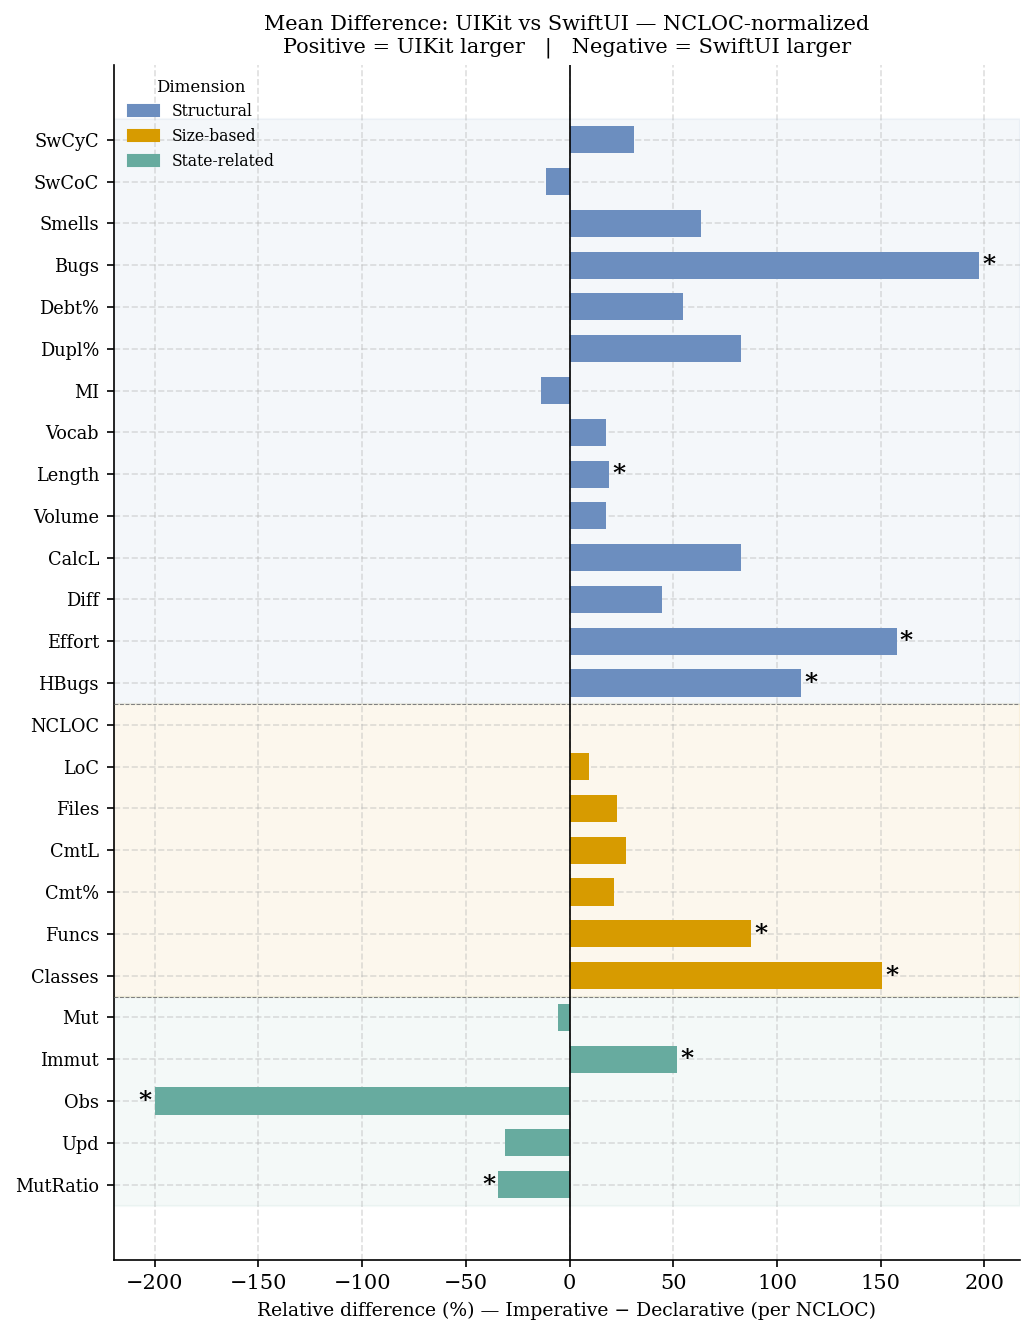

In [25]:
plot_rows_norm = []
for cat, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df.columns:
            continue
        a_vals, b_vals = get_paired_values_norm(metric)
        if len(a_vals) == 0:
            continue
        uikit_mean   = np.mean(a_vals)
        swiftui_mean = np.mean(b_vals)
        midpoint     = (uikit_mean + swiftui_mean) / 2
        diff_pct     = (uikit_mean - swiftui_mean) / midpoint * 100 if midpoint != 0 else 0.0

        row_stats = stats_df_norm[stats_df_norm['metric'] == metric]
        p_value   = row_stats['p_value'].values[0] if len(row_stats) else None

        plot_rows_norm.append({
            'category': cat,
            'metric':   metric,
            'diff_pct': diff_pct,
            'p_value':  p_value,
        })

plot_rows_norm.sort(key=lambda r: (cat_rank.get(r['category'], 99),
                                    list(METRIC_CATEGORIES.get(r['category'], [])).index(r['metric'])
                                    if r['metric'] in METRIC_CATEGORIES.get(r['category'], []) else 99))

labels_n    = [METRIC_LABELS.get(r['metric'], r['metric']) for r in plot_rows_norm]
values_n    = [r['diff_pct'] for r in plot_rows_norm]
colors_n    = [CAT_BAR_COLORS[r['category']] for r in plot_rows_norm]
sig_flags_n = [r['p_value'] is not None and not pd.isna(r['p_value']) and r['p_value'] < 0.05
               for r in plot_rows_norm]

fig, ax = plt.subplots(figsize=(7, 9))

ax.barh(range(len(labels_n)), values_n, color=colors_n, height=0.65, zorder=3)

for i, (val, sig) in enumerate(zip(values_n, sig_flags_n)):
    if sig:
        x_offset = 1.5 if val >= 0 else -1.5
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + x_offset, i, '*', va='center', ha=ha,
                fontsize=12, fontweight='bold', color='black')

ax.axvline(0, color='black', linewidth=0.8, zorder=5)
ax.set_yticks(range(len(labels_n)))
ax.set_yticklabels(labels_n, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel('Relative difference (%) — Imperative − Declarative (per NCLOC)', fontsize=9)
ax.set_title('Mean Difference: UIKit vs SwiftUI — NCLOC-normalized\n'
             'Positive = UIKit larger   |   Negative = SwiftUI larger',
             fontsize=10)

cat_sizes_n = [sum(1 for r in plot_rows_norm if r['category'] == c) for c in category_order]
cat_patches = [mpatches.Patch(color=CAT_BAR_COLORS[c], label=c) for c in category_order]

ax.legend(handles=cat_patches, fontsize=7.5,
          loc='upper left', title='Dimension', title_fontsize=8)

sep = 0
for size in cat_sizes_n[:-1]:
    sep += size
    ax.axhline(sep - 0.5, color='grey', linewidth=0.5, linestyle='--', zorder=4)

sep = 0
for cat, size in zip(category_order, cat_sizes_n):
    ax.axhspan(sep - 0.5, sep + size - 0.5,
               color=CAT_BAR_COLORS[cat], alpha=0.07, zorder=0)
    sep += size

ax.grid(True, axis='x', alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'ios_mean_difference_norm.pdf')
plt.show()

---
## Dominant-Framework Files Only — Wilcoxon Tests & Mean Difference

Same statistical analysis as above, restricted to files belonging to the **dominant UI framework** in each project (e.g. only SwiftUI files in a SwiftUI-dominant project). Data loaded from `results/dominant_results/`.

For NCLOC normalization, `hal_loc` (LOC summed over dominant files) replaces `sq_ncloc` — the SonarQube project scan covers the full project and would overcount.  
Most `sq_*` project-level metrics are unavailable for dominant iOS results (SonarCloud analyses failed) and will be skipped automatically.

In [26]:
import csv as csv_module

# Map project name → (repo_label in repo_data_ios.csv, prefix to strip from CSV paths)
PROJ_IOS_CSV_MAP = {
    'fearless-iOS':        ('soramitsu/fearless-iOS', ''),
    'gem-ios':             ('gemwalletcom/gem-ios', ''),
    'OnionBrowser':        ('OnionBrowser/OnionBrowser', ''),
    'ACHNBrowserUI':       ('Dimillian/ACHNBrowserUI', ''),
    'youtube-iOS':         ('aslanyanhaik/youtube-iOS', ''),
    'MovieSwiftUI':        ('Dimillian/MovieSwiftUI', ''),
    'Expense-Tracker-App': ('abdorizak/Expense-Tracker-App', ''),
    'dimeApp':             ('rafsoh/DimeApp', ''),
    'Chess':               ('nicklockwood/Chess', ''),
    'chess_swiftui':       ('jaredcassoutt/chess_swiftui', ''),
    'Tuist-Pokedex':       ('ronanociosoig/Tuist-Pokedex', ''),
    'PokedexUI':           ('brillcp/PokedexUI', ''),
    'YouTag':              ('youstanzr/YouTag', ''),
    'LyricFever':          ('aviwad/LyricFever', ''),
}

# Build (repo_label, file_path) → framework lookup from repo_data_ios.csv
_csv_fw_ios: dict = {}
with open(Path('../repo_data_ios.csv'), newline='', encoding='utf-8') as _f:
    for _row in csv_module.DictReader(_f):
        _csv_fw_ios[(_row['repo'], _row['file_path'])] = _row['framework']


def get_dominant_files_ios(proj_name: str, files_dict: dict) -> dict:
    """Filter files_dict to dominant-framework files only using CSV classification."""
    if proj_name not in PROJ_IOS_CSV_MAP:
        print(f"  Warning: no CSV mapping for '{proj_name}', using all files")
        return files_dict
    repo_label, strip_prefix = PROJ_IOS_CSV_MAP[proj_name]

    fw_for_file: dict = {}
    for fpath in files_dict:
        csv_fpath = strip_prefix + fpath
        fw = _csv_fw_ios.get((repo_label, csv_fpath)) or _csv_fw_ios.get((repo_label, fpath))
        if fw:
            fw_for_file[fpath] = fw

    counts: dict = {}
    for fw in fw_for_file.values():
        if 'Mixed' not in fw:
            counts[fw] = counts.get(fw, 0) + 1
    if not counts:
        return files_dict
    dominant_fw = max(counts, key=counts.get)
    dominant_words = set(dominant_fw.split())

    return {
        fpath: fdata
        for fpath, fdata in files_dict.items()
        if fw_for_file.get(fpath) == dominant_fw
    }


# SonarQube fields consistently available in iOS per-file data (summed)
_SQ_SUM_IOS = ['ncloc', 'lines', 'classes', 'functions', 'comment_lines', 'complexity']


def aggregate_project_dominant_ios(data: dict, dominant_files: dict) -> dict:
    """Same aggregation as aggregate_project but over dominant_files only.
    SQ metrics aggregated from per-file sonarqube data (not the project-level scan)."""
    row: dict = {}
    project_path = data.get('project_path', '')
    row['project']   = Path(project_path).name if project_path else data.get('project', '')
    row['framework'] = data.get('framework', '')

    sq_sums: dict = {f: [] for f in _SQ_SUM_IOS}
    for file_data in dominant_files.values():
        sq = file_data.get('sonarqube', {})
        for field in _SQ_SUM_IOS:
            val = sq.get(field)
            if val is not None:
                try:
                    sq_sums[field].append(float(val))
                except (TypeError, ValueError):
                    pass

    for field in SONARQUBE_FIELDS:
        if field in _SQ_SUM_IOS:
            vals = sq_sums[field]
            row[f'sq_{field}'] = sum(vals) if vals else None
        elif field == 'files':
            row['sq_files'] = len(dominant_files)
        elif field == 'comment_lines_density':
            c  = sum(sq_sums['comment_lines']) if sq_sums['comment_lines'] else None
            ln = sum(sq_sums['lines'])          if sq_sums['lines']         else None
            row['sq_comment_lines_density'] = round(c / ln * 100, 1) if c and ln else None
        else:
            row[f'sq_{field}'] = None

    hal = collect_file_values(dominant_files, 'halstead', HALSTEAD_SUM_FIELDS + HALSTEAD_MEDIAN_FIELDS)
    for field in HALSTEAD_SUM_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = sum(vals) if vals else None
    for field in HALSTEAD_MEDIAN_FIELDS:
        vals = hal[field]
        row[f'hal_{field}'] = float(np.median(vals)) if vals else None

    state = collect_file_values(dominant_files, 'state_metrics', STATE_SUM_FIELDS)
    for field in STATE_SUM_FIELDS:
        vals = state[field]
        row[f'state_{field}'] = sum(vals) if vals else None

    total_mutable   = row.get('state_mutable_vars') or 0
    total_immutable = row.get('state_immutable_vars') or 0
    total_vars      = total_mutable + total_immutable
    row['derived_mutable_variable_ratio'] = round(total_mutable / total_vars, 4) if total_vars > 0 else None

    derived = collect_file_values(dominant_files, 'derived', DERIVED_MEDIAN_FIELDS)
    for field in DERIVED_MEDIAN_FIELDS:
        vals = derived[field]
        row[f'derived_{field}'] = float(np.median(vals)) if vals else None


    # Swift complexity — sum across dominant files only
    swift_total_cognitive  = 0
    swift_total_cyclomatic = 0
    has_swift = False
    for file_data in dominant_files.values():
        sc = file_data.get('swift_complexity', {})
        if not sc:
            continue
        has_swift = True
        for fn in sc.get('functions', []):
            swift_total_cognitive  += fn.get('cognitive',  0)
            swift_total_cyclomatic += fn.get('cyclomatic', 0)
    row['swift_total_cognitive']  = swift_total_cognitive  if has_swift else None
    row['swift_total_cyclomatic'] = swift_total_cyclomatic if has_swift else None
    return row


filter_rows = []
rows_dom = []
for result_file in result_files:
    with open(result_file) as f:
        data = json.load(f)
    proj_name = Path(data.get('project_path', '')).name or data.get('project', '')
    all_files = data.get('files', {})
    dominant_files = get_dominant_files_ios(proj_name, all_files)
    print(f"  {data['framework']}/{proj_name}: {len(all_files)} total → {len(dominant_files)} dominant files")
    rows_dom.append(aggregate_project_dominant_ios(data, dominant_files))
    filter_rows.append({
        'Framework': data['framework'],
        'Project': proj_name,
        'Total files': len(all_files),
        'Dominant files': len(dominant_files),
        'Filtered out': len(all_files) - len(dominant_files),
    })

df_dom = pd.DataFrame(rows_dom).set_index(['framework', 'project'])
print(f'\nShape: {df_dom.shape}')
df_dom

  swiftui/ACHNBrowserUI: 161 total → 152 dominant files
  swiftui/chess_swiftui: 5 total → 5 dominant files
  swiftui/gem-ios: 270 total → 260 dominant files
  swiftui/LyricFever: 36 total → 33 dominant files
  swiftui/MovieSwiftUI: 91 total → 88 dominant files
  swiftui/PokedexUI: 29 total → 25 dominant files
  swiftui/dimeApp: 81 total → 64 dominant files
  uikit/Chess: 6 total → 4 dominant files
  uikit/Expense-Tracker-App: 58 total → 45 dominant files
  uikit/OnionBrowser: 62 total → 54 dominant files
  uikit/Tuist-Pokedex: 42 total → 30 dominant files
  uikit/YouTag: 23 total → 23 dominant files
  uikit/youtube-iOS: 14 total → 14 dominant files
  uikit/fearless-iOS: 62 total → 49 dominant files

Shape: (14, 34)


sq_ncloc  sq_lines  sq_files  sq_functions  \
framework project                                                           
swiftui   ACHNBrowserUI       10180.000 12927.000       152       227.000   
          chess_swiftui         742.000   992.000         5        24.000   
          gem-ios             19495.000 22894.000       260       532.000   
          LyricFever           3911.000  4864.000        33        85.000   
          MovieSwiftUI         5304.000  6846.000        88       143.000   
          PokedexUI            1049.000  1390.000        25        51.000   
          dimeApp             15500.000 19734.000        64       166.000   
uikit     Chess                 375.000   453.000         4        29.000   
          Expense-Tracker-App  3543.000  4993.000        45       218.000   
          OnionBrowser         5530.000  8542.000        54       291.000   
          Tuist-Pokedex        1067.000  1603.000        30       107.000   
          YouTag               6138.000  7989.000        23       343.000   
          youtube-iOS           989.000  1530.000        14        93.000   
          fearless-iOS         1514.000  1892.000        49        94.000   

                               sq_classes sq_statements  sq_complexity  \
framework project                                                        
swiftui   ACHNBrowserUI            23.000          None       1396.000   
          chess_swiftui             1.000          None        174.000   
          gem-ios                  49.000          None       1186.000   
          LyricFever                4.000          None        208.000   
          MovieSwiftUI              6.000          None        928.000   
          PokedexUI                 4.000          None         74.000   
          dimeApp                   8.000          None        662.000   
uikit     Chess                     4.000          None         87.000   
          Expense-Tracker-App      38.000          None        316.000   
          OnionBrowser            110.000          None        778.000   
          Tuist-Pokedex            26.000          None        156.000   
          YouTag                   25.000          None        808.000   
          youtube-iOS              29.000          None        168.000   
          fearless-iOS             19.000          None        209.000   

                              sq_code_smells sq_bugs sq_sqale_debt_ratio  \
framework project                                                          
swiftui   ACHNBrowserUI                 None    None                None   
          chess_swiftui                 None    None                None   
          gem-ios                       None    None                None   
          LyricFever                    None    None                None   
          MovieSwiftUI                  None    None                None   
          PokedexUI                     None    None                None   
          dimeApp                       None    None                None   
uikit     Chess                         None    None                None   
          Expense-Tracker-App           None    None                None   
          OnionBrowser                  None    None                None   
          Tuist-Pokedex                 None    None                None   
          YouTag                        None    None                None   
          youtube-iOS                   None    None                None   
          fearless-iOS                  None    None                None   

                              sq_duplicated_lines_density  sq_comment_lines  \
framework project                                                             
swiftui   ACHNBrowserUI                              None          1161.000   
          chess_swiftui                              None           103.000   
          gem-ios                                    None           412.000   
 

In [27]:
pd.DataFrame(filter_rows).set_index(['Framework', 'Project'])

Total files  Dominant files  Filtered out
Framework Project                                                       
swiftui   ACHNBrowserUI                161             152             9
          chess_swiftui                  5               5             0
          gem-ios                      270             260            10
          LyricFever                    36              33             3
          MovieSwiftUI                  91              88             3
          PokedexUI                     29              25             4
          dimeApp                       81              64            17
uikit     Chess                          6               4             2
          Expense-Tracker-App           58              45            13
          OnionBrowser                  62              54             8
          Tuist-Pokedex                 42              30            12
          YouTag                        23              23             0
          youtube-iOS                   14              14             0
          fearless-iOS                  62              49            13

### Dominant files — raw (unnormalized)

UIKit = imperative, SwiftUI = declarative.  
p < 0.05 = statistically significant.  
Effect r: negligible < 0.1, small 0.1–0.3, medium 0.3–0.5, large > 0.5.  
Note: `sq_*` metrics are sparse — only pairs where both projects have SonarQube data are included.

22 metrics tested (dominant files, raw)


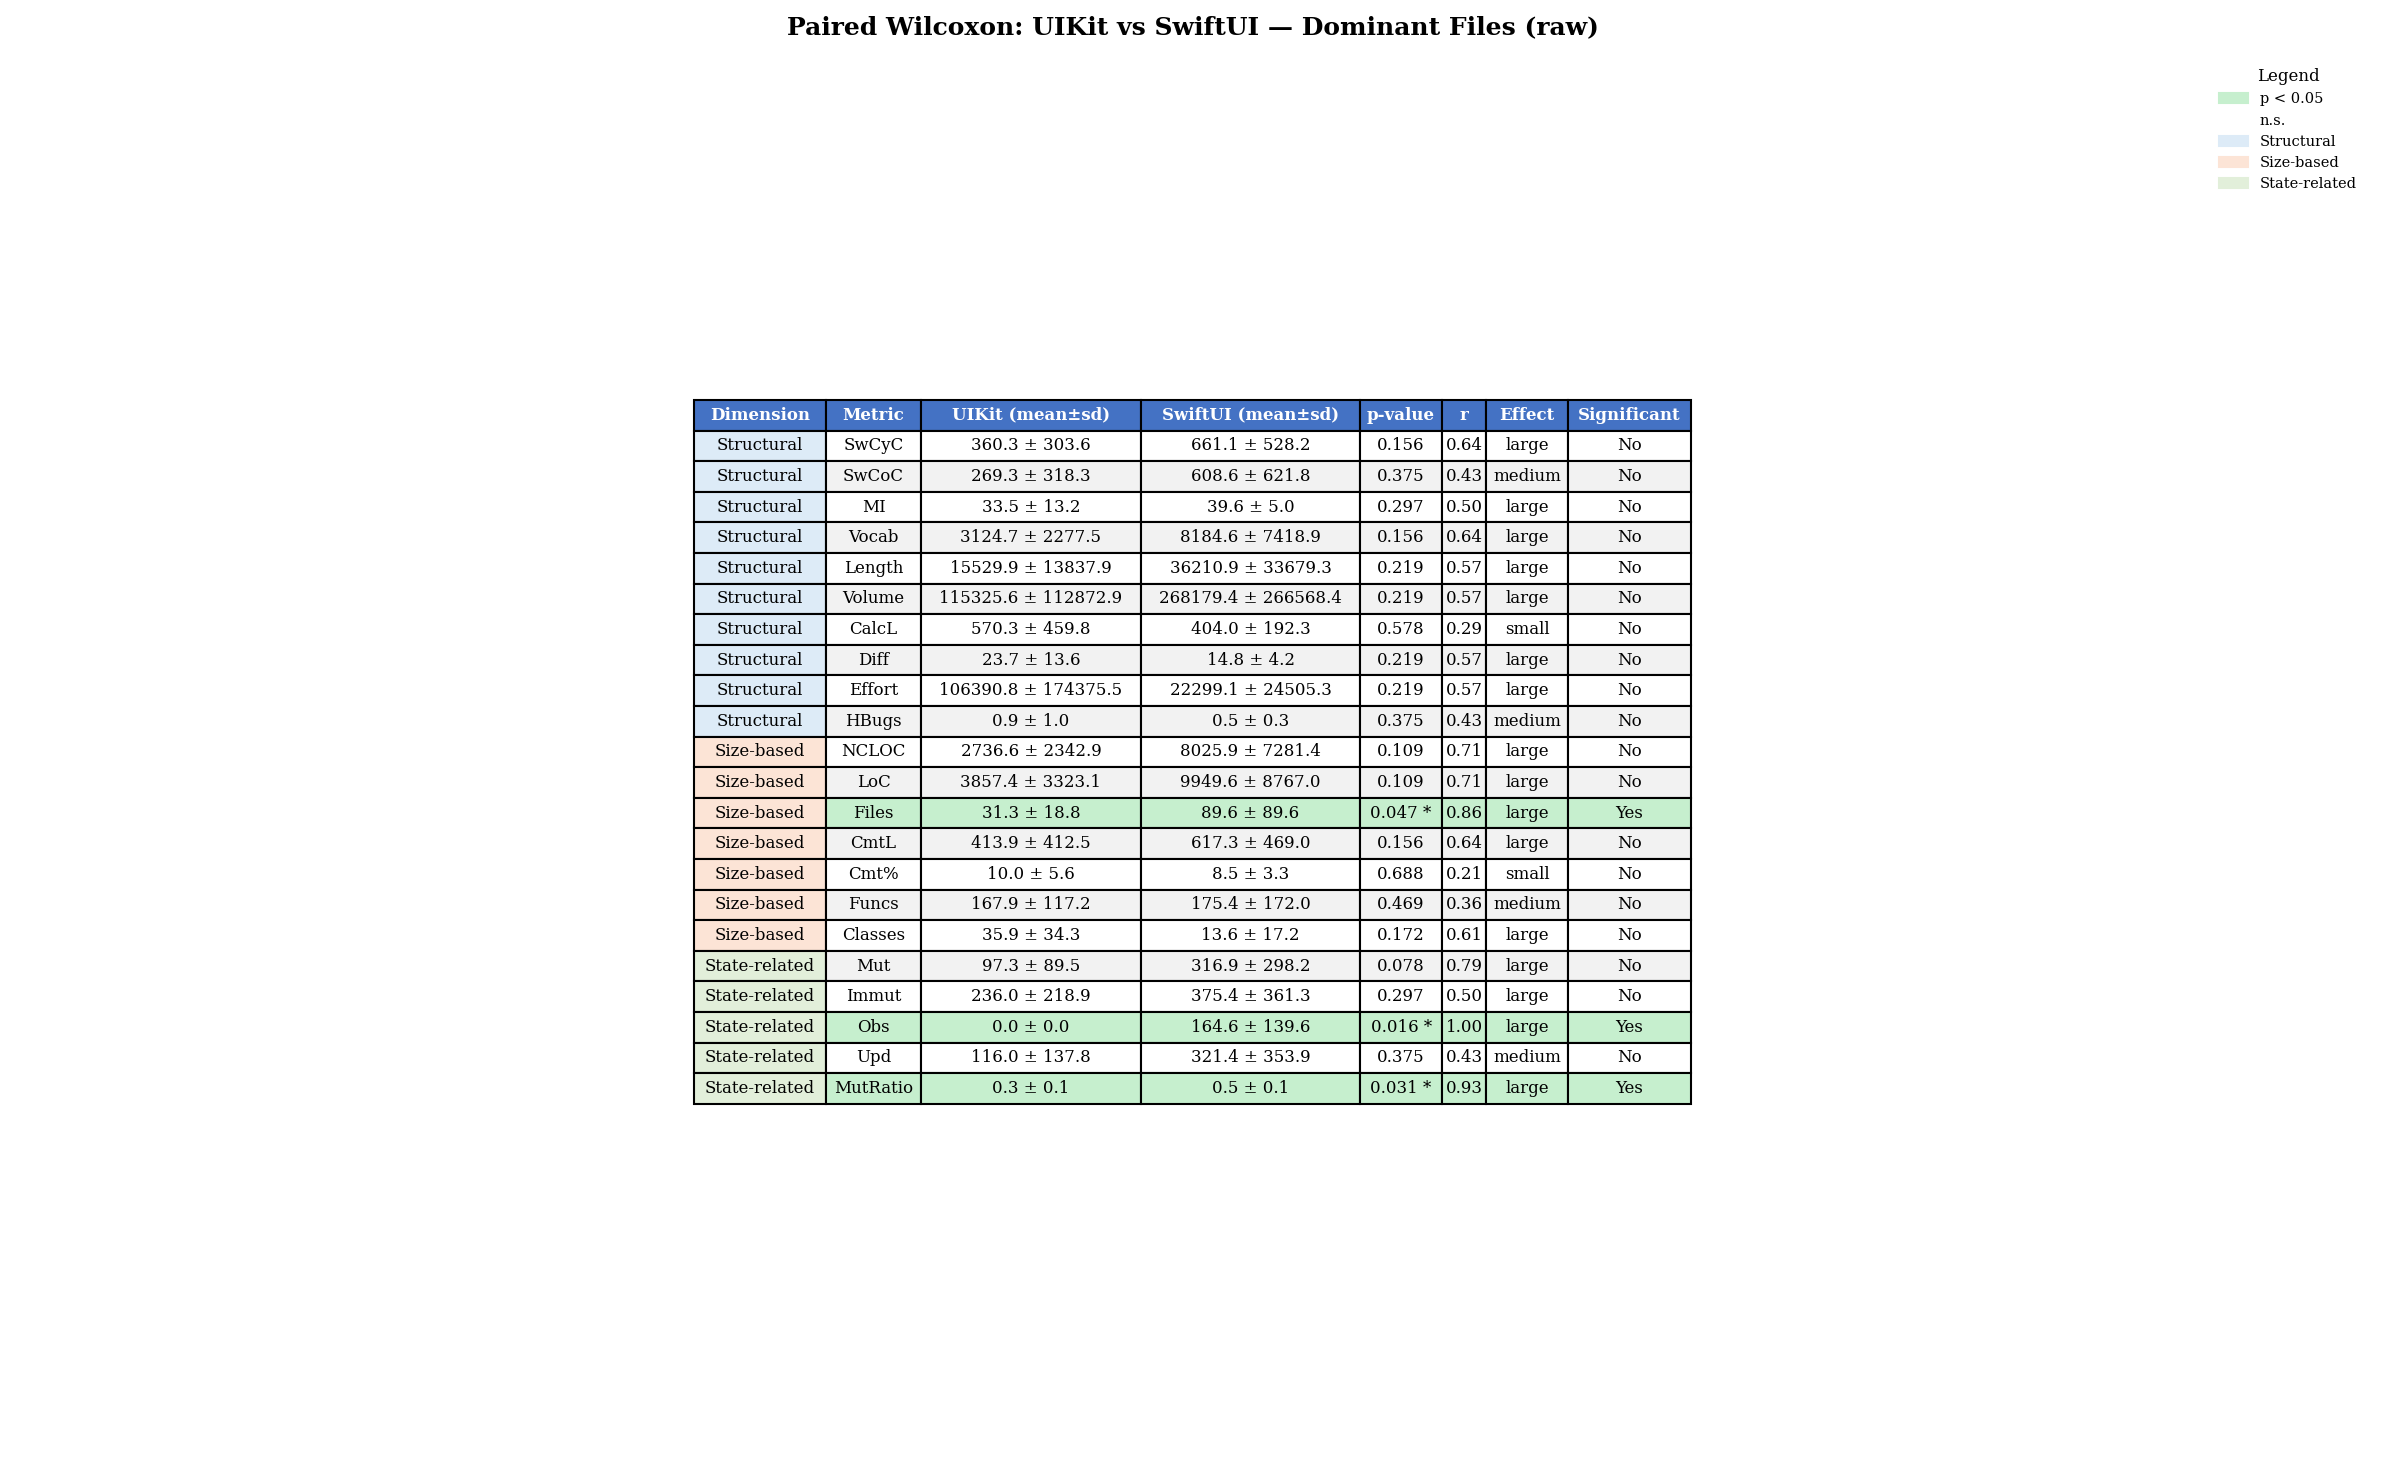

In [28]:
results_dom_raw = []
for category, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df_dom.columns:
            continue
        a_vals, b_vals = [], []
        for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
            idx_a, idx_b = (fw_a, proj_a), (fw_b, proj_b)
            if idx_a not in df_dom.index or idx_b not in df_dom.index:
                continue
            va, vb = df_dom.loc[idx_a, metric], df_dom.loc[idx_b, metric]
            if pd.isna(va) or pd.isna(vb):
                continue
            a_vals.append(float(va)); b_vals.append(float(vb))
        a_arr, b_arr = np.array(a_vals), np.array(b_vals)
        if len(a_arr) == 0:
            continue
        p, r, mag = wilcoxon_test(a_arr, b_arr)
        results_dom_raw.append({
            'category': category, 'metric': metric,
            'uikit_mean':   np.mean(a_arr), 'uikit_std':   np.std(a_arr, ddof=1),
            'swiftui_mean': np.mean(b_arr), 'swiftui_std': np.std(b_arr, ddof=1),
            'p_value': p, 'effect_r': r, 'effect_size': mag, 'n_pairs': len(a_arr),
        })

stats_df_dom_raw = pd.DataFrame(results_dom_raw)
print(f'{len(stats_df_dom_raw)} metrics tested (dominant files, raw)')

disp_dr = []
for _, row in stats_df_dom_raw.iterrows():
    p = row['p_value']
    sig = p is not None and not pd.isna(p) and p < 0.05
    disp_dr.append({
        'Dimension': row['category'], 'Metric': METRIC_LABELS.get(row['metric'], row['metric']),
        'UIKit (mean±sd)':   fmt_mean_std(row['uikit_mean'],   row['uikit_std']),
        'SwiftUI (mean±sd)': fmt_mean_std(row['swiftui_mean'], row['swiftui_std']),
        'p-value': fmt_p(p),
        'r': f"{row['effect_r']:.2f}" if row['effect_r'] is not None and not pd.isna(row['effect_r']) else '—',
        'Effect': row['effect_size'] or '—',
        'Significant': 'Yes' if sig else 'No',
    })

tbl_dr = pd.DataFrame(disp_dr)
_cols = ['UIKit (mean±sd)', 'SwiftUI (mean±sd)', 'p-value', 'r', 'Effect', 'Significant']
_hdrs = ['Dimension', 'Metric'] + _cols
_ctxt, _cclr = [], []
for i, row in tbl_dr.iterrows():
    sig = row['Significant'] == 'Yes'
    base = SIG_COLOR if sig else (NONSIG_COLOR if i % 2 == 0 else ALT_COLOR)
    _ctxt.append([row['Dimension'], row['Metric']] + [str(row[c]) for c in _cols])
    _cclr.append([CAT_COLORS.get(row['Dimension'], '#FFF'), base] + [base] * len(_cols))
fig, ax = plt.subplots(figsize=(16, max(4, len(_ctxt) * 0.38 + 1.5)))
ax.axis('off')
t = ax.table(cellText=_ctxt, colLabels=_hdrs, cellColours=_cclr, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(8); t.auto_set_column_width(col=list(range(len(_hdrs))))
for j in range(len(_hdrs)):
    t[0, j].set_facecolor(HEADER_COLOR); t[0, j].set_text_props(color='white', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=SIG_COLOR, label='p < 0.05'),
                   mpatches.Patch(color=NONSIG_COLOR, label='n.s.')] +
                  [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()],
          loc='upper right', fontsize=7, title='Legend', title_fontsize=8)
plt.title('Paired Wilcoxon: UIKit vs SwiftUI — Dominant Files (raw)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / 'dominant_ios_stats_table.png', dpi=300, bbox_inches='tight')
plt.show()

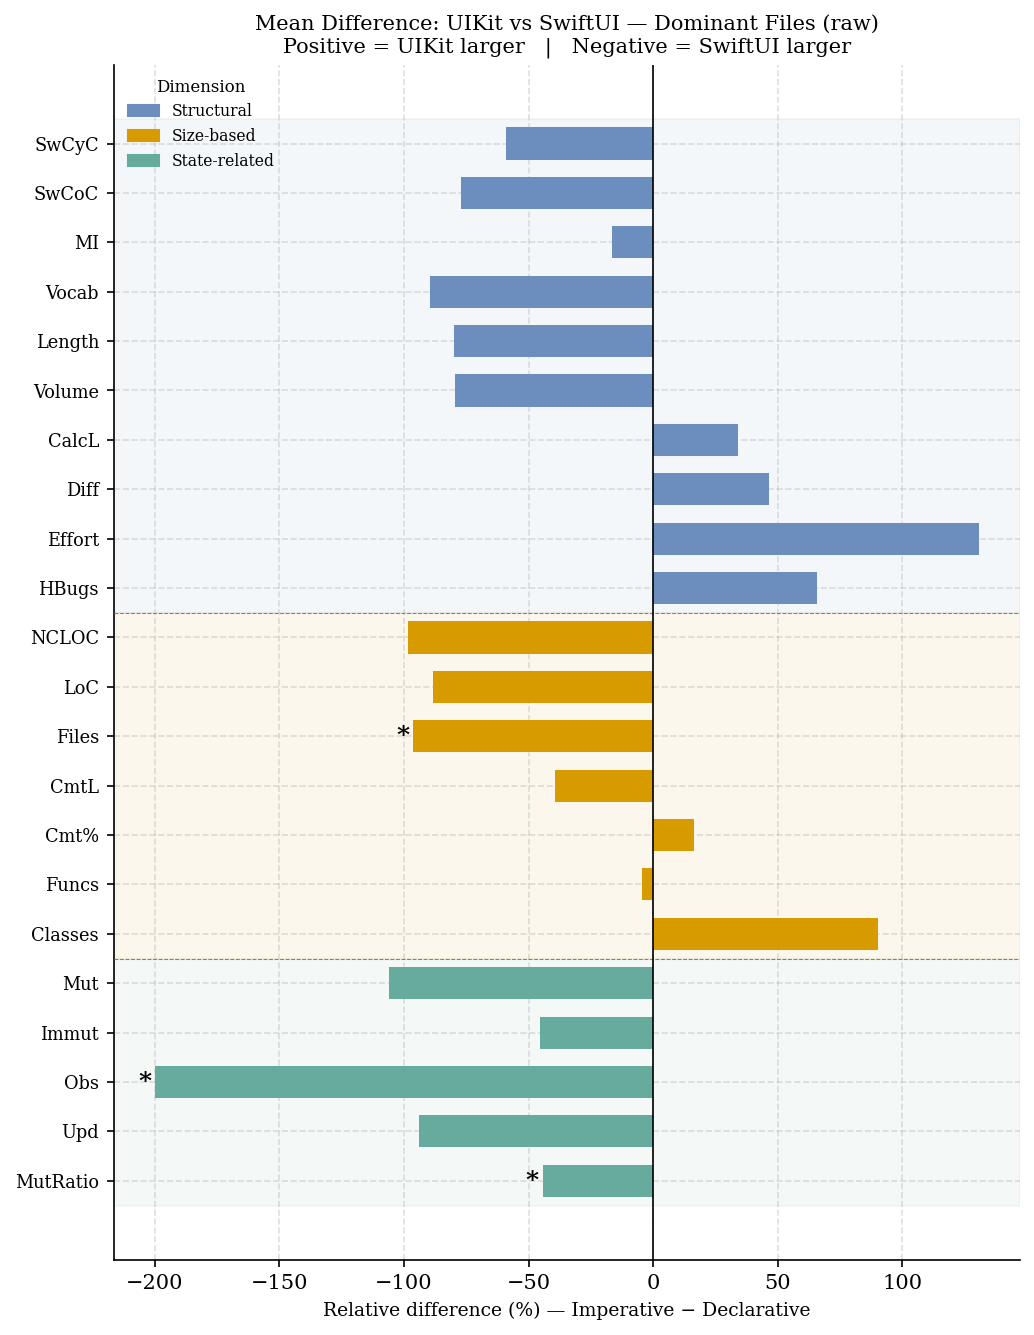

In [29]:
plot_rows_dr = []
for cat, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df_dom.columns:
            continue
        a_vals, b_vals = [], []
        for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
            idx_a, idx_b = (fw_a, proj_a), (fw_b, proj_b)
            if idx_a not in df_dom.index or idx_b not in df_dom.index:
                continue
            va, vb = df_dom.loc[idx_a, metric], df_dom.loc[idx_b, metric]
            if pd.isna(va) or pd.isna(vb):
                continue
            a_vals.append(float(va)); b_vals.append(float(vb))
        if not a_vals:
            continue
        a_arr, b_arr = np.array(a_vals), np.array(b_vals)
        mid = (np.mean(a_arr) + np.mean(b_arr)) / 2
        diff = (np.mean(a_arr) - np.mean(b_arr)) / mid * 100 if mid else 0.0
        row_s = stats_df_dom_raw[stats_df_dom_raw['metric'] == metric]
        plot_rows_dr.append({'category': cat, 'metric': metric, 'diff_pct': diff,
                             'p_value': row_s['p_value'].values[0] if len(row_s) else None})

plot_rows_dr.sort(key=lambda r: (cat_rank.get(r['category'], 99),
    list(METRIC_CATEGORIES.get(r['category'], [])).index(r['metric'])
    if r['metric'] in METRIC_CATEGORIES.get(r['category'], []) else 99))

fig, ax = plt.subplots(figsize=(7, 9))
_labs = [METRIC_LABELS.get(r['metric'], r['metric']) for r in plot_rows_dr]
_vals = [r['diff_pct'] for r in plot_rows_dr]
_clrs = [CAT_BAR_COLORS[r['category']] for r in plot_rows_dr]
_sigs = [r['p_value'] is not None and not pd.isna(r['p_value']) and r['p_value'] < 0.05
         for r in plot_rows_dr]
ax.barh(range(len(_labs)), _vals, color=_clrs, height=0.65, zorder=3)
for i, (v, s) in enumerate(zip(_vals, _sigs)):
    if s:
        ax.text(v + (1.5 if v >= 0 else -1.5), i, '*', va='center',
                ha='left' if v >= 0 else 'right', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, zorder=5)
ax.set_yticks(range(len(_labs))); ax.set_yticklabels(_labs, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel('Relative difference (%) — Imperative − Declarative', fontsize=9)
ax.set_title('Mean Difference: UIKit vs SwiftUI — Dominant Files (raw)\n'
             'Positive = UIKit larger   |   Negative = SwiftUI larger', fontsize=10)
_csz = [sum(1 for r in plot_rows_dr if r['category'] == c) for c in category_order]
ax.legend(handles=[mpatches.Patch(color=CAT_BAR_COLORS[c], label=c) for c in category_order] ,
          fontsize=7.5, loc='upper left', title='Dimension', title_fontsize=8)
sep = 0
for sz in _csz[:-1]:
    sep += sz; ax.axhline(sep - 0.5, color='grey', linewidth=0.5, linestyle='--', zorder=4)
sep = 0
for cat, sz in zip(category_order, _csz):
    ax.axhspan(sep - 0.5, sep + sz - 0.5, color=CAT_BAR_COLORS[cat], alpha=0.07, zorder=0); sep += sz
ax.grid(True, axis='x', alpha=0.4, linestyle='--'); ax.set_axisbelow(True)
fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'dominant_ios_mean_difference.pdf')
plt.show()

### Dominant files — NCLOC-normalized

Each count-based metric is divided by `sq_ncloc` (sum of per-file NCLOC over dominant files only).  
Ratio and index metrics are left as-is (already size-independent).

22 metrics tested (dominant, sq_ncloc-normalized)


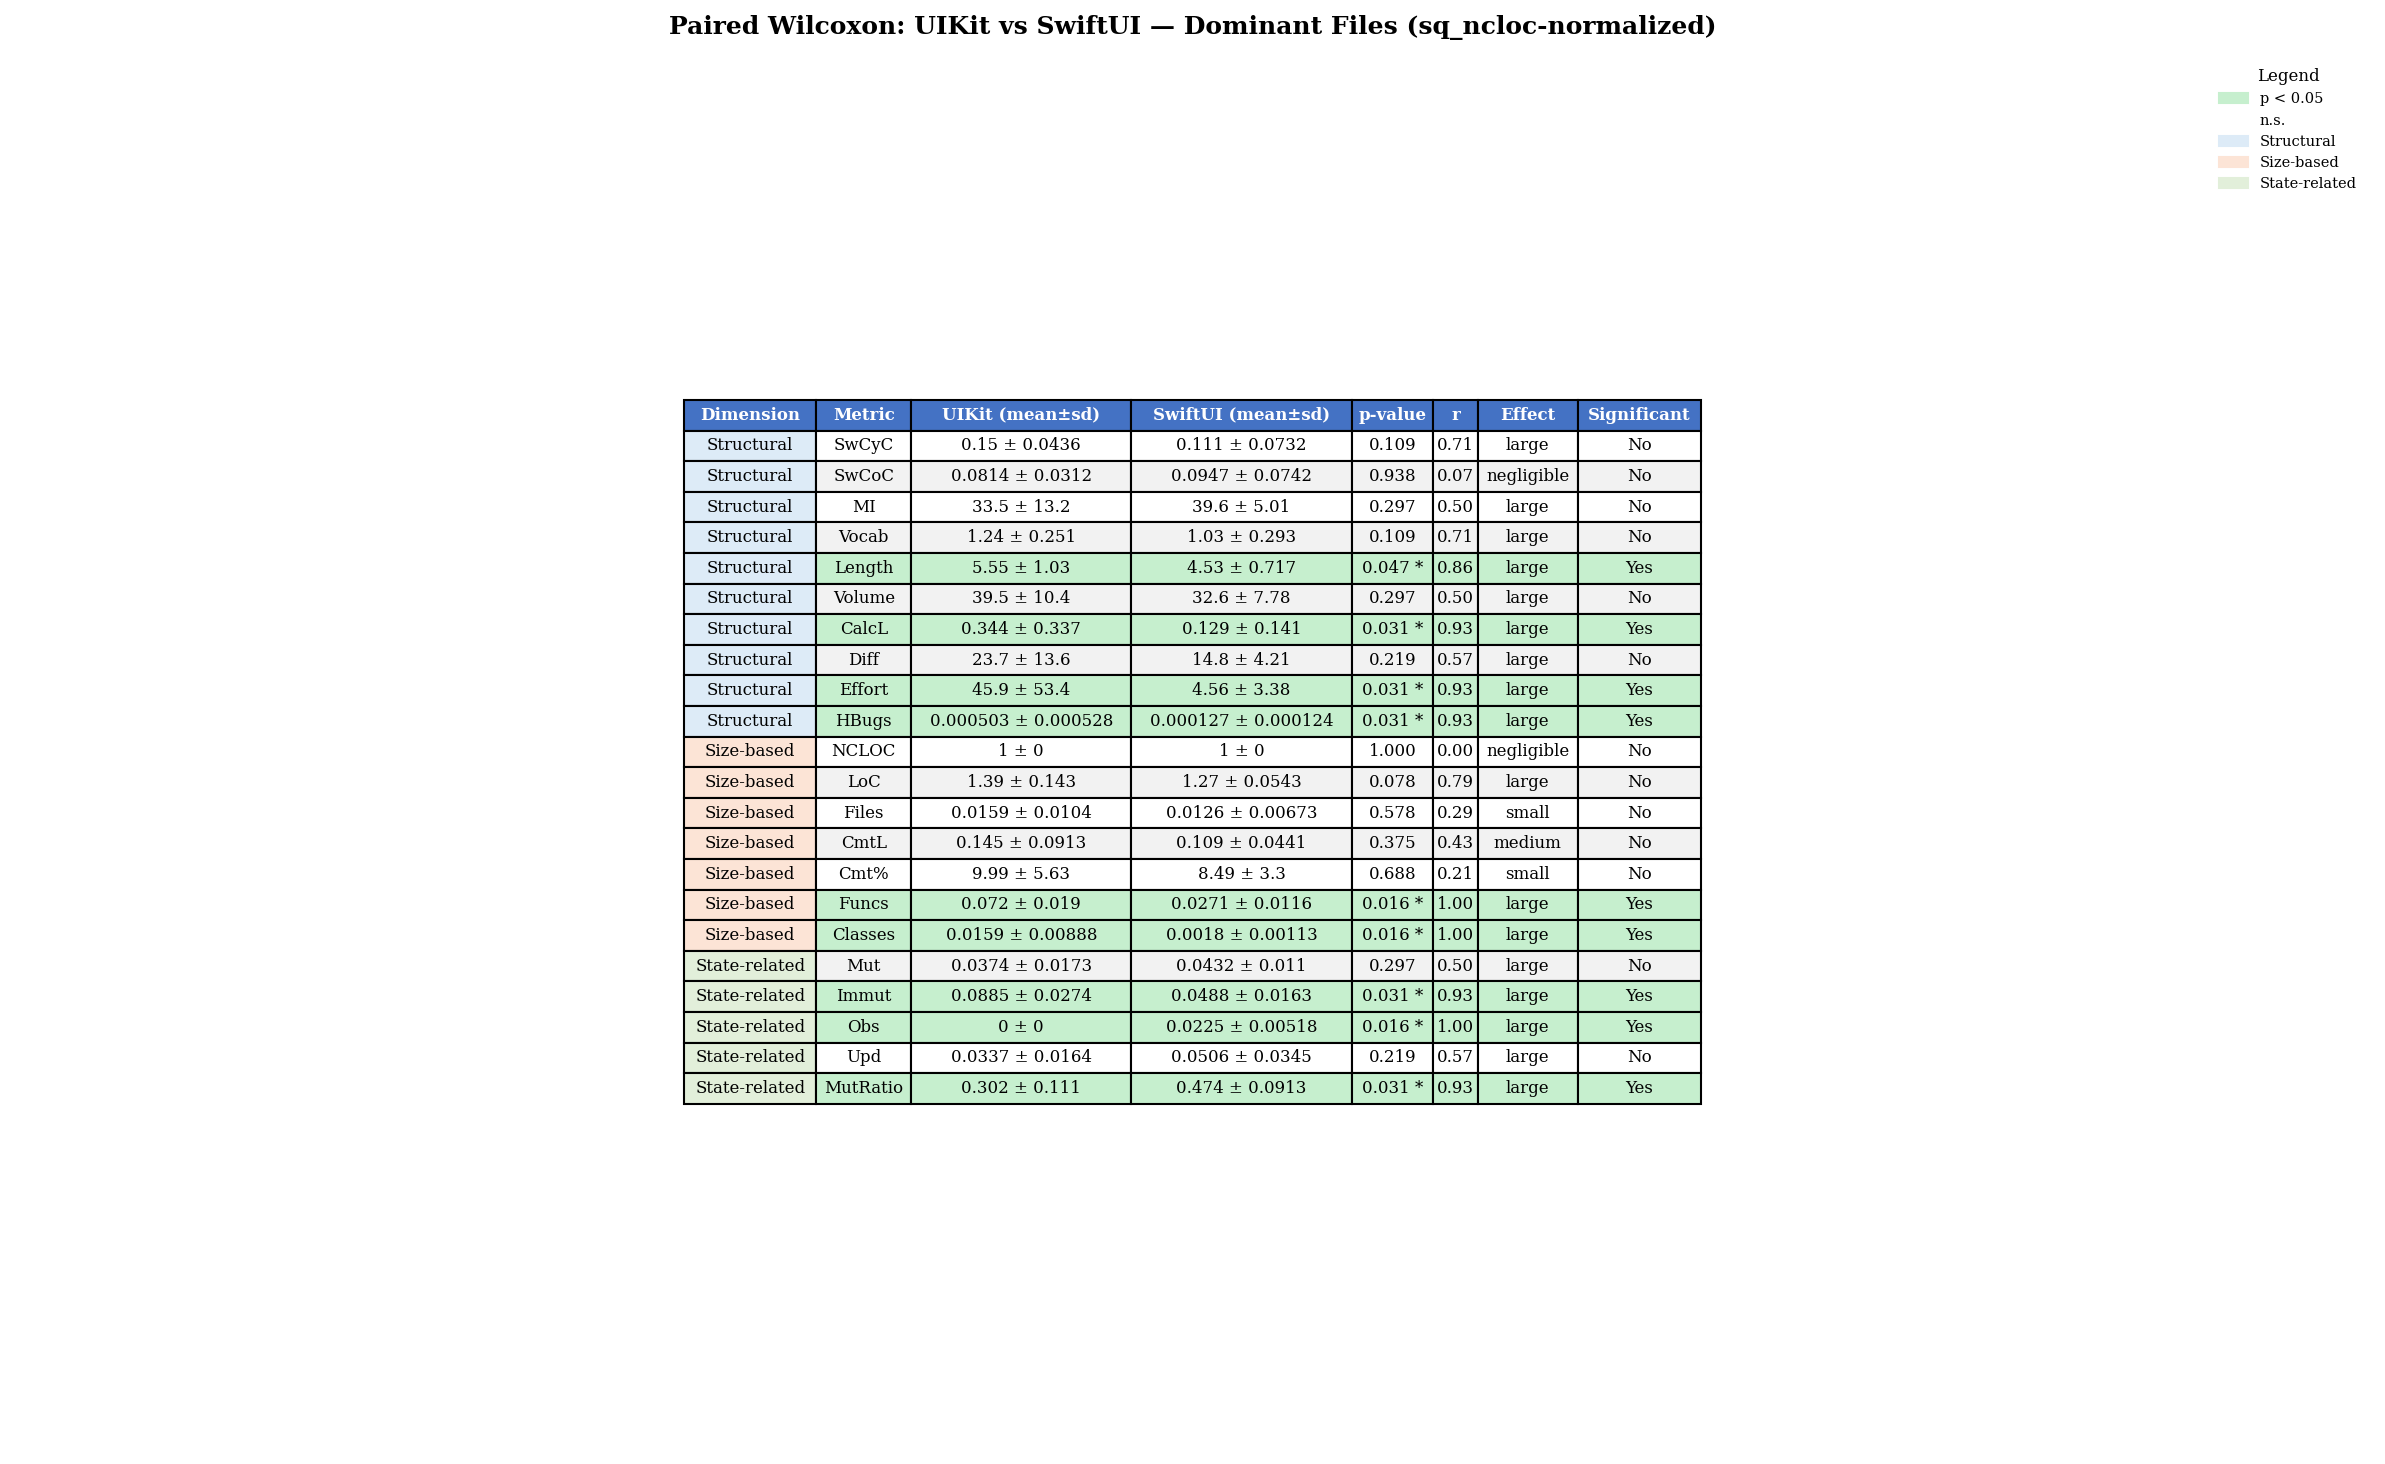

In [30]:
results_dom_norm = []
for category, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df_dom.columns:
            continue
        a_vals, b_vals = [], []
        for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
            idx_a, idx_b = (fw_a, proj_a), (fw_b, proj_b)
            if idx_a not in df_dom.index or idx_b not in df_dom.index:
                continue
            va, vb = df_dom.loc[idx_a, metric], df_dom.loc[idx_b, metric]
            if pd.isna(va) or pd.isna(vb):
                continue
            if metric not in LOC_NORMALIZE_SKIP:
                loc_a, loc_b = df_dom.loc[idx_a, 'sq_ncloc'], df_dom.loc[idx_b, 'sq_ncloc']
                if pd.isna(loc_a) or pd.isna(loc_b) or loc_a == 0 or loc_b == 0:
                    continue
                va, vb = float(va) / float(loc_a), float(vb) / float(loc_b)
            a_vals.append(float(va)); b_vals.append(float(vb))
        a_arr, b_arr = np.array(a_vals), np.array(b_vals)
        if len(a_arr) == 0:
            continue
        p, r, mag = wilcoxon_test(a_arr, b_arr)
        results_dom_norm.append({
            'category': category, 'metric': metric,
            'uikit_mean':   np.mean(a_arr), 'uikit_std':   np.std(a_arr, ddof=1),
            'swiftui_mean': np.mean(b_arr), 'swiftui_std': np.std(b_arr, ddof=1),
            'p_value': p, 'effect_r': r, 'effect_size': mag, 'n_pairs': len(a_arr),
        })

stats_df_dom_norm = pd.DataFrame(results_dom_norm)
print(f'{len(stats_df_dom_norm)} metrics tested (dominant, sq_ncloc-normalized)')

disp_dn = []
for _, row in stats_df_dom_norm.iterrows():
    p = row['p_value']
    sig = p is not None and not pd.isna(p) and p < 0.05
    disp_dn.append({
        'Dimension': row['category'], 'Metric': METRIC_LABELS.get(row['metric'], row['metric']),
        'UIKit (mean±sd)':   fmt_mean_std_norm(row['uikit_mean'],   row['uikit_std']),
        'SwiftUI (mean±sd)': fmt_mean_std_norm(row['swiftui_mean'], row['swiftui_std']),
        'p-value': fmt_p(p),
        'r': f"{row['effect_r']:.2f}" if row['effect_r'] is not None and not pd.isna(row['effect_r']) else '—',
        'Effect': row['effect_size'] or '—',
        'Significant': 'Yes' if sig else 'No',
    })

tbl_dn = pd.DataFrame(disp_dn)
_cols = ['UIKit (mean±sd)', 'SwiftUI (mean±sd)', 'p-value', 'r', 'Effect', 'Significant']
_hdrs = ['Dimension', 'Metric'] + _cols
_ctxt, _cclr = [], []
for i, row in tbl_dn.iterrows():
    sig = row['Significant'] == 'Yes'
    base = SIG_COLOR if sig else (NONSIG_COLOR if i % 2 == 0 else ALT_COLOR)
    _ctxt.append([row['Dimension'], row['Metric']] + [str(row[c]) for c in _cols])
    _cclr.append([CAT_COLORS.get(row['Dimension'], '#FFF'), base] + [base] * len(_cols))
fig, ax = plt.subplots(figsize=(16, max(4, len(_ctxt) * 0.38 + 1.5)))
ax.axis('off')
t = ax.table(cellText=_ctxt, colLabels=_hdrs, cellColours=_cclr, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(8); t.auto_set_column_width(col=list(range(len(_hdrs))))
for j in range(len(_hdrs)):
    t[0, j].set_facecolor(HEADER_COLOR); t[0, j].set_text_props(color='white', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=SIG_COLOR, label='p < 0.05'),
                   mpatches.Patch(color=NONSIG_COLOR, label='n.s.')] +
                  [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()],
          loc='upper right', fontsize=7, title='Legend', title_fontsize=8)
plt.title('Paired Wilcoxon: UIKit vs SwiftUI — Dominant Files (sq_ncloc-normalized)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / 'dominant_ios_stats_table_norm.png', dpi=300, bbox_inches='tight')
plt.show()

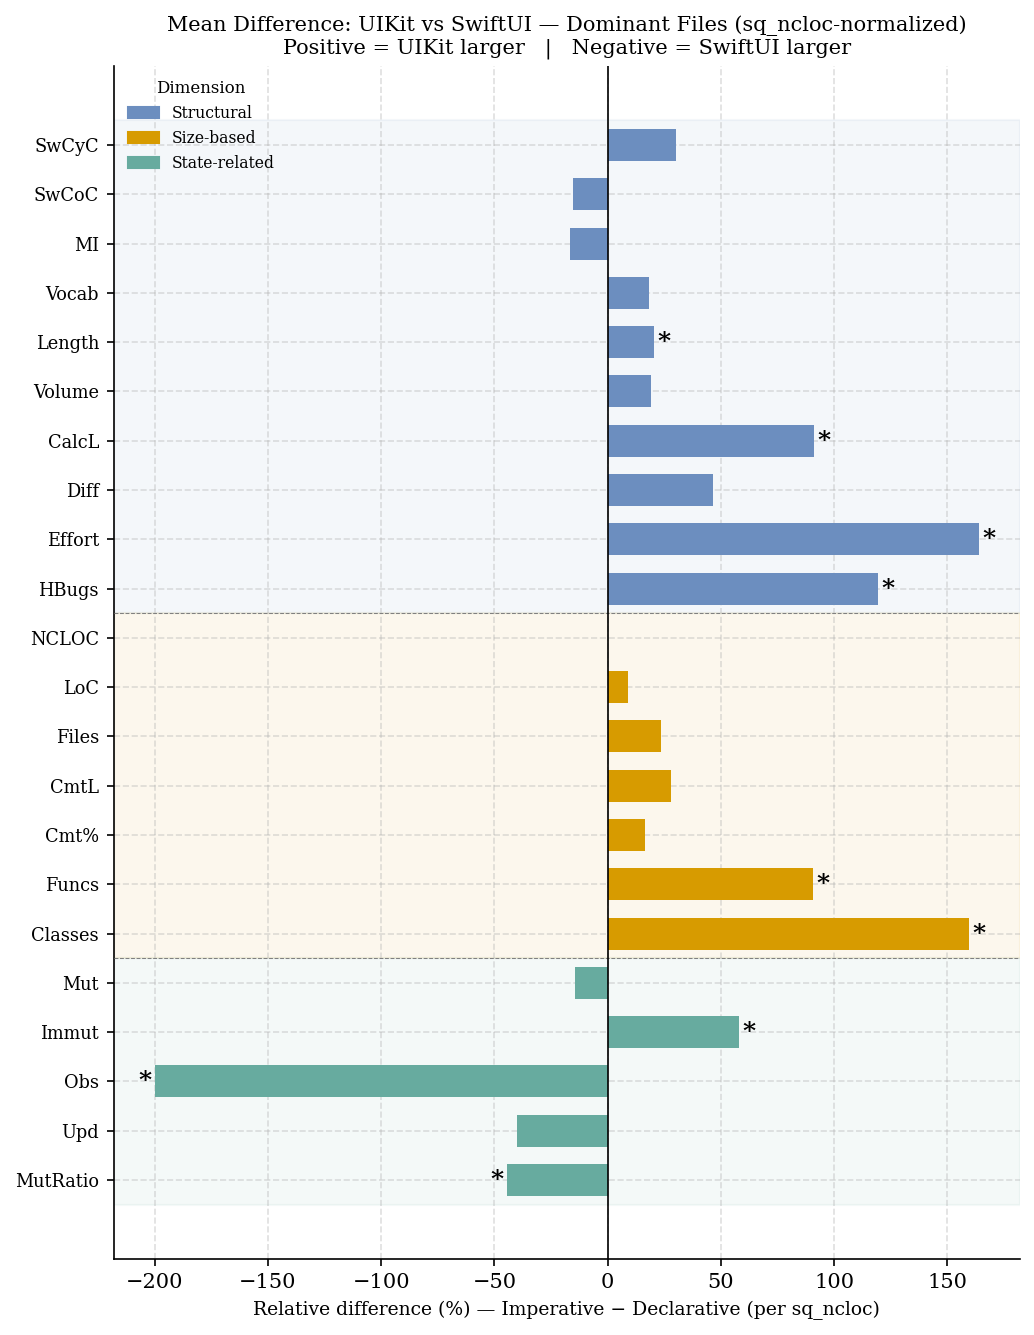

In [31]:
plot_rows_dn = []
for cat, metrics in METRIC_CATEGORIES.items():
    for metric in metrics:
        if metric not in df_dom.columns:
            continue
        a_vals, b_vals = [], []
        for fw_a, proj_a, _, fw_b, proj_b, _, _ in PAIRS:
            idx_a, idx_b = (fw_a, proj_a), (fw_b, proj_b)
            if idx_a not in df_dom.index or idx_b not in df_dom.index:
                continue
            va, vb = df_dom.loc[idx_a, metric], df_dom.loc[idx_b, metric]
            if pd.isna(va) or pd.isna(vb):
                continue
            if metric not in LOC_NORMALIZE_SKIP:
                loc_a, loc_b = df_dom.loc[idx_a, 'sq_ncloc'], df_dom.loc[idx_b, 'sq_ncloc']
                if pd.isna(loc_a) or pd.isna(loc_b) or loc_a == 0 or loc_b == 0:
                    continue
                va, vb = float(va) / float(loc_a), float(vb) / float(loc_b)
            a_vals.append(float(va)); b_vals.append(float(vb))
        if not a_vals:
            continue
        a_arr, b_arr = np.array(a_vals), np.array(b_vals)
        mid = (np.mean(a_arr) + np.mean(b_arr)) / 2
        diff = (np.mean(a_arr) - np.mean(b_arr)) / mid * 100 if mid else 0.0
        row_s = stats_df_dom_norm[stats_df_dom_norm['metric'] == metric]
        plot_rows_dn.append({'category': cat, 'metric': metric, 'diff_pct': diff,
                             'p_value': row_s['p_value'].values[0] if len(row_s) else None})

plot_rows_dn.sort(key=lambda r: (cat_rank.get(r['category'], 99),
    list(METRIC_CATEGORIES.get(r['category'], [])).index(r['metric'])
    if r['metric'] in METRIC_CATEGORIES.get(r['category'], []) else 99))

fig, ax = plt.subplots(figsize=(7, 9))
_labs = [METRIC_LABELS.get(r['metric'], r['metric']) for r in plot_rows_dn]
_vals = [r['diff_pct'] for r in plot_rows_dn]
_clrs = [CAT_BAR_COLORS[r['category']] for r in plot_rows_dn]
_sigs = [r['p_value'] is not None and not pd.isna(r['p_value']) and r['p_value'] < 0.05
         for r in plot_rows_dn]
ax.barh(range(len(_labs)), _vals, color=_clrs, height=0.65, zorder=3)
for i, (v, s) in enumerate(zip(_vals, _sigs)):
    if s:
        ax.text(v + (1.5 if v >= 0 else -1.5), i, '*', va='center',
                ha='left' if v >= 0 else 'right', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, zorder=5)
ax.set_yticks(range(len(_labs))); ax.set_yticklabels(_labs, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel('Relative difference (%) — Imperative − Declarative (per sq_ncloc)', fontsize=9)
ax.set_title('Mean Difference: UIKit vs SwiftUI — Dominant Files (sq_ncloc-normalized)\n'
             'Positive = UIKit larger   |   Negative = SwiftUI larger', fontsize=10)
_csz = [sum(1 for r in plot_rows_dn if r['category'] == c) for c in category_order]
ax.legend(handles=[mpatches.Patch(color=CAT_BAR_COLORS[c], label=c) for c in category_order] ,
          fontsize=7.5, loc='upper left', title='Dimension', title_fontsize=8)
sep = 0
for sz in _csz[:-1]:
    sep += sz; ax.axhline(sep - 0.5, color='grey', linewidth=0.5, linestyle='--', zorder=4)
sep = 0
for cat, sz in zip(category_order, _csz):
    ax.axhspan(sep - 0.5, sep + sz - 0.5, color=CAT_BAR_COLORS[cat], alpha=0.07, zorder=0); sep += sz
ax.grid(True, axis='x', alpha=0.4, linestyle='--'); ax.set_axisbelow(True)
fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'dominant_ios_mean_difference_norm.pdf')
plt.show()